# SIG742 2026T2 Assignment 2 Starter Notebook: Group Forecasting Project

<div style="border: 3px solid #1d4ed8; padding: 0.9rem 1rem; border-radius: 6px; background: #eff6ff;">
<strong>Forecasting Performance Determines Your Final Grade Band</strong>
<p>Your Forecasting Performance Grade determines the grade band for your final A2 mark.</p>
<ul>
<li><strong>Forecasting measures:</strong> The grade is determined primarily by MASE. MAPE is used as supporting cross-check evidence.</li>
<li><strong>Questions Q1-Q7:</strong> Your marks for these questions determine the exact final mark within the grade band.</li>
<li><strong>Grade bands:</strong> HD: 80-100; D: 70-79; C: 60-69; P: 50-59; F: 0-49.</li>
</ul>
<p>For example, if your Forecasting Performance Grade is D, your final A2 mark will be between 70 and 79, with the exact mark determined by your marks for Questions Q1-Q7.</p>
</div>

Complete this notebook for Assignment 2. Preserve the required headings, function names, object names, and written-answer markers.

<div style="border: 2px solid #b91c1c; padding: 0.9rem 1rem; border-radius: 6px; background: #fef2f2;">
<strong>Required autograding markers</strong>
<p>Do not delete, rename, edit, move, or reorder any <code>A2:ANSWER</code> START/END marker comment. Write each response between the matching markers for that question. Changed or missing markers may prevent a response from being detected correctly during marking.</p>
</div>


<a id="table-of-contents"></a>
## Table of contents

- [Group details](#group-details)
- [Required scaffold and forecasting pipeline](#required-scaffold)
- [Assignment overview](#assignment-overview)
- [Setup and dataset loading](#setup-and-data)
  - [Validation and final-cutoff split objects](#data-splits)
- [Part I: Forecast functions and evaluation](#part-i)
  - [Q1: Naive-lag forecast generator](#q1)
  - [Q2: Forecast and actual table validation](#q2)
  - [Q3: Forecast accuracy measures](#q3)
  - [Integrated baseline evidence](#part-i-evidence)
- [Part II: Forecasting project](#part-ii)
  - [Q4: Forecasting workflow and model development](#q4)
    - [Exploratory data analysis](#eda)
      - [Univariate analysis](#eda-univariate)
      - [Multivariate analysis](#eda-multivariate)
      - [EDA findings and ADF interpretation](#eda-findings)
    - [Model 1: Naive lag-1](#model-naive-lag1)
    - [Model 2: Seasonal naive lag-12](#model-naive-lag12)
    - [Model 3: Seasonal recovery naive](#model-seasonal-recovery)
    - [Model 4: Blended recovery](#model-blended-recovery)
    - [Model 5: SARIMA](#model-sarima)
    - [Model 6: Prophet](#model-prophet)
    - [Model 7: TimesFM 2.5](#model-timesfm)
    - [Seven-model validation](#model-validation)
    - [12-month recovery-era backtest](#model-backtest)
    - [Model comparison and selection](#model-selection)
  - [Q5: Final forecast submission](#q5)
  - [Q6: Performance and market analysis](#q6)
    - [Four-market evidence](#market-evidence)
      - [Australia](#market-australia)
      - [Japan](#market-japan)
      - [New Zealand](#market-new-zealand)
      - [Taiwan China](#market-taiwan-china)
- [Part III: Group video and collaboration](#part-iii)
  - [Q7: Group video](#q7)
- [Dataset and external source acknowledgement](#sources)
- [Submission checklist](#submission-checklist)

<a id="group-details"></a>
## Group Details

Complete the group details before submission. Follow the Olympus Assignment requirements for peer/self-review and contribution material.

`email_username` is the part before `@deakin.edu.au`; for example, use `xyz` for `xyz@deakin.edu.au`. If your group has more or fewer than three members because of an approved arrangement, adjust the `members` list and explain this in the contribution/video evidence.


In [1]:
GROUP_INFO = {
    "group_id": "Team16",
    "group_name": "G3 - Team 16",
    "members": [
        {
            "student_id": "s226481467",
            "name": "Swaminathan Babu Rao",
            "deakin_email": "s226481467@deakin.edu.au",
            "email_username": "s226481467",
            "role_or_contribution": "Team Member",
        },
        {
            "student_id": "s226484081",
            "name": "Biswadeep DasGupta",
            "deakin_email": "s226484081@deakin.edu.au",
            "email_username": "s226484081",
            "role_or_contribution": "Team Member",
        },
        {
            "student_id": "s226485909",
            "name": "Rohit Jaiswal",
            "deakin_email": "s226485909@deakin.edu.au",
            "email_username": "s226485909",
            "role_or_contribution": "Team Member",
        },
    ],
    "unit": "SIG742",
    "assignment": "A2",
    "teaching_period": "2026T2",
}


In [2]:
A2_REQUIRED_OBJECTS = [
    "GROUP_INFO",
    "raw_tourism_data",
    "training_actual_wide_to_2023M02",
    "validation_actual_wide_2023M03_2023M07",
    "public_history_wide_to_2023M07",
    "baseline_lag1_validation_forecast_wide",
    "baseline_lag12_validation_forecast_wide",
    "baseline_lag1_validation_audit",
    "baseline_lag12_validation_audit",
    "baseline_validation_comparison",
    "baseline_validation_summary",
    "tourism_series_long",
    "modelling_data_or_feature_table",
    "external_feature_log",
    "validation_forecasts",
    "validation_metrics",
    "model_summary",
    "forecast_submission_wide",
    "forecast_submission_audit",
]

A2_REQUIRED_FUNCTIONS = [
    "generate_naive_forecast_wide",
    "validate_forecast_actual_wide",
    "evaluate_forecast_wide",
]


<a id="required-scaffold"></a>
## Required scaffold names and forecasting pipeline

Do not delete or rename required functions, objects, question headings, or written-answer markers. You may add helper cells, functions, models, packages, and intermediate variables.

Key required objects:

| Name | Meaning |
| --- | --- |
| `GROUP_INFO` | Group/member metadata, including Deakin email and email username. |
| `raw_tourism_data` | Public `ISF-TDF2023` dataset loaded into Python. |
| `training_actual_wide_to_2023M02` | Training actuals up to validation cutoff `2023M02`. |
| `validation_actual_wide_2023M03_2023M07` | Visible validation actual/result table. |
| `public_history_wide_to_2023M07` | Public history available at final cutoff `2023M07`. |
| `baseline_validation_comparison` | Destination-level MAE, MASE, MAPE, denominator diagnostics, and row counts for both required baselines. |
| `baseline_validation_summary` | Aggregate validation measures for both required baselines. |
| `tourism_series_long` | Long-format DataFrame with at least `Date`, `destination`, and `demand`. |
| `modelling_data_or_feature_table` | Cutoff-safe modelling data, feature table, or concise model-ready evidence summary. |
| `external_feature_log` | Fixed-column external-source DataFrame, or a zero-row DataFrame with those columns if no external data is used. |
| `validation_forecasts` | Long-format validation forecast DataFrame using `VALIDATION_FORECAST_COLUMNS`. |
| `validation_metrics` | Destination-level validation measure DataFrame using `VALIDATION_METRIC_COLUMNS`. |
| `model_summary` | One-row-per-model DataFrame using `MODEL_SUMMARY_COLUMNS`. |
| `forecast_submission_wide` | Final 12-row all-20 destination forecast table exported directly to CSV. |
| `forecast_submission_audit` | Fixed-key Q2 forecast-only audit for the final wide forecast table. |

Pipeline: Q1 creates naive wide baselines; Q2 audits schema/alignment; Q3 calculates measures; integrated Part I evidence creates baseline tables; Q4 develops models; Q5 exports final forecasts; Q6 interprets performance and markets; Q7 demonstrates reproducibility and collaboration.

<a id="assignment-overview"></a>
## Assignment overview

Build a reproducible forecasting workflow for the public TULIP Lab `ISF-TDF2023` tourism demand dataset. Forecast all 20 destination series for `2023M08` to `2024M07`, analyse selected markets, and submit a wide-format forecast CSV with one row per forecast month.

Assessment structure: Part I functions 15 marks, Part II forecasting project 70 marks, compulsory group video 15 marks. Any forecasting method is allowed if it is cutoff-safe, reproducible, stable enough for assessment, and interpretable.

<div style="border: 2px solid #475569; padding: 0.9rem 1rem; border-radius: 6px; background: #f8fafc;">
<strong>Reproducibility and Stability</strong>
<p>The notebook should rerun from a clean runtime, preserve required names, document inputs and seeds where relevant, regenerate the final CSV from `forecast_submission_wide`, and avoid local absolute paths, manual CSV edits, placeholder forecasts, or uncontrolled stochastic outputs.</p>
</div>

Final output: `forecast_submission_wide` with one `Date` column, exactly 12 rows for `2023M08` to `2024M07`, and exactly the 20 public-dataset destination columns. Export the final CSV directly from this object with `index=False`.

Performance measures: MASE and MAPE are both required. MAE is used where needed to support MASE numerator checking. See the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md) for definitions and worked examples. See the [A2 Function Examples Guide](SIG742-2026T2-A2-Function-Examples.md) for detailed Q1-Q3 toy inputs, expected outputs, and function I/O examples.


<a id="setup-and-data"></a>
## Setup and dataset loading

This section provides a Google Colab / online execution option using a public raw URL. You may add a local execution option if your group uses a cloned repository, but do not rely on absolute local paths.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
import matplotlib.pyplot as plt

%matplotlib inline


In [4]:
DATA_URL = "https://raw.githubusercontent.com/tulip-lab/open-data/main/ISF-TDF2023/ISF-TDF2023.csv"

TRAIN_END = "2023M02"
VALIDATION_MONTHS = [f"2023M{month:02d}" for month in range(3, 8)]
VALIDATION_START = VALIDATION_MONTHS[0]
VALIDATION_END = VALIDATION_MONTHS[-1]
FORECAST_MONTHS = [f"2023M{month:02d}" for month in range(8, 13)] + [f"2024M{month:02d}" for month in range(1, 8)]
FORECAST_START = FORECAST_MONTHS[0]
FORECAST_END = FORECAST_MONTHS[-1]
FINAL_FORECAST_MONTHS = FORECAST_MONTHS

FOCUS_REQUIRED_DESTINATIONS = ["Australia", "Japan"]
FINAL_FORECAST_DATE_COLUMN = "Date"

Q2_AUDIT_FIELDS = [
    "is_valid",
    "can_align",
    "forecast_row_count",
    "actual_row_count",
    "expected_row_count",
    "missing_months_in_forecast",
    "missing_months_in_actual",
    "extra_months_in_forecast",
    "extra_months_in_actual_source",
    "missing_destinations_in_forecast",
    "missing_destinations_in_actual",
    "extra_columns_in_forecast",
    "duplicate_forecast_dates",
    "duplicate_actual_dates",
    "missing_forecast_value_count",
    "missing_actual_value_count",
    "nonnumeric_forecast_value_count",
    "nonnumeric_actual_value_count",
    "nonfinite_forecast_value_count",
    "nonfinite_actual_value_count",
]

DESTINATION_METRIC_COLUMNS = [
    "destination",
    "n",
    "mae",
    "mase",
    "mape",
    "denominator",
    "n_denominator_pairs",
    "mase_available",
    "denominator_warning",
]
AGGREGATE_METRIC_FIELDS = [
    "n_destinations",
    "mean_mase",
    "median_mase",
    "mean_mape",
]

EXTERNAL_FEATURE_LOG_COLUMNS = [
    "source_name",
    "source_url_or_reference",
    "local_file_or_url",
    "retrieval_date",
    "publication_or_release_date",
    "latest_observation_used",
    "cutoff_applicable",
    "features_created",
    "transformation_summary",
    "licence_or_access_notes",
]
VALIDATION_FORECAST_COLUMNS = [
    "model_label",
    "Date",
    "destination",
    "forecast",
]
VALIDATION_METRIC_COLUMNS = ["model_label"] + DESTINATION_METRIC_COLUMNS
MODEL_SUMMARY_COLUMNS = [
    "model_label",
    "model_family",
    "n_destinations",
    "mean_mase",
    "median_mase",
    "mean_mape",
    "selected",
    "selection_rationale",
    "reproducibility_notes",
    "stability_notes",
]

BASELINE_COMPARISON_COLUMNS = [
    "model_label",
    "lag",
] + DESTINATION_METRIC_COLUMNS
BASELINE_SUMMARY_COLUMNS = [
    "model_label",
    "lag",
] + AGGREGATE_METRIC_FIELDS

In [5]:
# Option A: Google Colab / online execution.
raw_tourism_data = pd.read_csv(DATA_URL)

# Option B: local execution, if you have deliberately saved a local copy.
# local_path = Path("data") / "ISF-TDF2023.csv"
# raw_tourism_data = pd.read_csv(local_path)

DESTINATION_COLUMNS = [column for column in raw_tourism_data.columns if column != FINAL_FORECAST_DATE_COLUMN]
FINAL_FORECAST_COLUMNS = [FINAL_FORECAST_DATE_COLUMN] + DESTINATION_COLUMNS
REQUIRED_DESTINATIONS = DESTINATION_COLUMNS

# Inspect the first few rows during your own work.
# raw_tourism_data.head()


<a id="data-splits"></a>
### Validation and final-cutoff split objects

Create these required scaffold objects from `raw_tourism_data` using the `Date` column and the existing constants. Use a real year-month representation such as `pandas.Period(..., freq="M")`; do not filter by direct string comparison on month labels.

- `training_actual_wide_to_2023M02`: used for validation MASE denominators, validation MAPE alignment, and validation baseline generation cutoff.
- `validation_actual_wide_2023M03_2023M07`: visible validation actual/result table used for Q1-Q3 integrated evidence and Q4 validation comparison.
- `public_history_wide_to_2023M07`: public history available for the final forecasting cutoff and final MASE denominator concept; no final-evaluation actual/result values are included.


In [6]:
def month_label_to_period(month_label):
    """Convert a YYYYMmm label such as '2023M02' into a monthly Period."""
    return pd.Period(str(month_label).replace("M", "-"), freq="M")


raw_tourism_data_with_period = raw_tourism_data.copy()
raw_tourism_data_with_period["_month_period"] = raw_tourism_data_with_period[
    FINAL_FORECAST_DATE_COLUMN
].map(month_label_to_period)

training_actual_wide_to_2023M02 = raw_tourism_data_with_period.loc[
    raw_tourism_data_with_period["_month_period"] <= month_label_to_period(TRAIN_END),
    FINAL_FORECAST_COLUMNS,
].reset_index(drop=True)

validation_periods = [month_label_to_period(month) for month in VALIDATION_MONTHS]
validation_actual_wide_2023M03_2023M07 = raw_tourism_data_with_period.loc[
    raw_tourism_data_with_period["_month_period"].isin(validation_periods),
    FINAL_FORECAST_COLUMNS,
].reset_index(drop=True)

public_history_wide_to_2023M07 = raw_tourism_data_with_period.loc[
    raw_tourism_data_with_period["_month_period"] <= month_label_to_period("2023M07"),
    FINAL_FORECAST_COLUMNS,
].reset_index(drop=True)

# The helper column _month_period is not part of the required wide tables.
print("training_actual_wide_to_2023M02:", training_actual_wide_to_2023M02.shape)
print("validation_actual_wide_2023M03_2023M07:", validation_actual_wide_2023M03_2023M07.shape)
print("public_history_wide_to_2023M07:", public_history_wide_to_2023M07.shape)

training_actual_wide_to_2023M02: (410, 21)
validation_actual_wide_2023M03_2023M07: (5, 21)
public_history_wide_to_2023M07: (415, 21)


<a id="part-i"></a>
## Part I: Forecast table generation and evaluation functions

Use the [A2 Function Examples Guide](SIG742-2026T2-A2-Function-Examples.md) for detailed Q1-Q3 input/output examples. Use the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md) for MASE/MAPE definitions and examples.

<a id="q1"></a>
### Q1. General naive-lag forecast table generator [5 marks]

Implement `generate_naive_forecast_wide(historical_actual_wide, cutoff_label, forecast_months, required_destinations=None, lag=1, date_column="Date")`.

Requirements: accept a wide actual table; return a pandas DataFrame with exactly one row per requested month; use all destination columns when `required_destinations=None`; otherwise forecast exactly the supplied destinations; use only values available at or before `cutoff_label`; support positive integer `lag`, especially `lag=1` and `lag=12`; support arbitrary forecast months and all destinations; compute recursive lag forecasts in chronological month order; avoid string subtraction for month labels.

Return rows in the supplied `forecast_months` order. Return columns in the exact order `date_column`, followed by the inferred or supplied destination order. Do not return an index column, `model_label`, diagnostics, or other extra columns.

Lag rule: for forecast month `m`, use source month `m - lag`. If the source month is after the cutoff but has already been forecast, use that generated forecast recursively. If no source value is available, return `NaN` or raise a clear error.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q1 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q1:START -->
---
### What is a naive-lag forecast?

A naive-lag forecast predicts a future value by copying the observed value from a fixed number of periods earlier. For a forecast month $m$ and a positive lag $k$, the rule is $\hat{y}_m = y_{m-k}$.

For example, a lag-1 forecast uses the previous month's value, while a lag-12 forecast uses the value from the same month one year earlier. It is a simple baseline for judging whether more advanced forecasting models provide an improvement. When a required source month is after the historical cutoff, the Q1 generator applies the same rule recursively using an earlier forecast that it has already generated.

#### `generate_naive_forecast_wide` documentation

**Purpose.** `generate_naive_forecast_wide` creates a wide-format naive-lag forecast from a wide table of historical actual values. For every destination $d$ and requested forecast month $m$, it applies the rule $\hat{y}_{m,d}=y_{m-k,d}$, where $k$ is the selected lag. A lag of 1 uses the previous month, while a lag of 12 uses the same month from the previous year.

**Parameters**

| Parameter | Meaning |
|---|---|
| `historical_actual_wide` | A pandas DataFrame containing one date column and one column per destination. Each row represents a month of observed values. |
| `cutoff_label` | The final month whose values are treated as observed and available to the forecast, expressed as a label such as `2023M02`. Rows after this cutoff are ignored to prevent future-data leakage. |
| `forecast_months` | An ordered sequence of month labels to forecast. The returned rows preserve this supplied order. |
| `required_destinations` | Optional ordered list of destination columns to forecast. When it is `None`, every column except `date_column` is used in its original DataFrame order. |
| `lag` | Positive integer number of months between the target month and its source month. Common values are `1` for a recent-value baseline and `12` for a seasonal annual baseline. |
| `date_column` | Name of the month-label column. It defaults to `"Date"`. |

**How the function works.**

1. It validates that `lag` is a positive integer; zero, negative values, Boolean values, and non-integers raise a clear `ValueError`.
2. It checks that the date column and every requested destination column exist. It also normalises the destination and forecast-month inputs to lists. An empty forecast-month list returns an empty DataFrame with the required columns.
3. It converts the cutoff, historical dates, and requested dates to pandas monthly `Period` objects. It keeps only cutoff-safe observations, resolves duplicate historical months by retaining the last supplied row, and indexes the values by period.
4. It iterates chronologically from the first month after the cutoff to the latest requested future month. For each period, it looks up `period - lag`; the newly generated value is stored in `values_by_period`, so it can become the source for a later recursive forecast.
5. Generating the complete intermediate monthly range means non-consecutive requested months still follow the recursive lag rule without using Python function recursion.
6. It constructs the final rows from the stored values using the original labels and order from `forecast_months`, and returns exactly the date column followed by the selected destination columns.

**Recursive forecasting example**

- Assume the cutoff is `2023M02`, the February value is 120, and `lag=1`.
- The forecast for `2023M03` uses the February value, so the result is 120.
- The forecast for `2023M04` needs the March value. Since March is after the cutoff, the function uses its March forecast, giving 120 again.
- If a required intermediate month is not listed in `forecast_months`, it is still calculated internally.

**Output and edge cases**

- The output is a new pandas DataFrame containing only the date and requested destination columns.
- Months and destinations stay in the order supplied by the user.
- No index, model label, or diagnostic columns are added.
- If the required source month is missing, the forecast is `NaN`. Any later forecast that depends on it will also be `NaN`.
- A missing date or destination column raises an explicit `ValueError`. Invalid month labels raise a pandas period-parsing error, making the problem visible instead of changing the output silently.

---
<!-- A2:ANSWER:Q1:END -->

#### Optional month-label helper example

This optional helper example only shows one way to convert labels such as `2023M03` into a month-aware representation. You may implement your own helper inside Q1. Do not use string subtraction for month arithmetic.


In [7]:
def month_label_to_period_example(month_label):
    """Optional example: convert a YYYYMmm label to a pandas monthly Period."""
    return pd.Period(str(month_label).replace("M", "-"), freq="M")


def period_to_month_label_example(period):
    """Optional example: convert a pandas monthly Period back to YYYYMmm."""
    return f"{period.year}M{period.month:02d}"

# Example only:
# month_label_to_period_example("2024M01") - 12


In [8]:
def _month_label_to_period(month_label):
    """Convert a YYYYMmm label such as '2023M08' into a monthly Period."""
    return pd.Period(str(month_label).replace("M", "-"), freq="M")


def generate_naive_forecast_wide(
    historical_actual_wide,
    cutoff_label,
    forecast_months,
    required_destinations=None,
    lag=1,
    date_column="Date",
):
    """Generate a cutoff-safe naive-lag forecast in wide-table format.

    In plain language, the forecast for a month repeats the value observed
    `lag` calendar months earlier. A lag of one carries forward the previous
    month, while a lag of twelve repeats the same month from the previous year.
    Only observations at or before `cutoff_label` are eligible, preventing
    future actuals from leaking into the forecast.

    Future source months are generated chronologically, so a forecast can reuse
    an earlier generated forecast without using recursive Python calls. Month
    labels are converted to pandas Period values for correct calendar arithmetic,
    duplicate historical months keep their last row, and a missing source month
    produces NaN. The result has one row per requested month, preserves the
    requested month and destination order, and contains no extra columns.
    """
    if not isinstance(lag, int) or isinstance(lag, bool) or lag <= 0:
        raise ValueError(f"lag must be a positive integer, got {lag!r}")

    if date_column not in historical_actual_wide.columns:
        raise ValueError(f"Missing date column: {date_column!r}")

    # Infer destinations only when the caller does not supply an explicit
    # order; this keeps the output schema predictable for the autograder.
    if required_destinations is None:
        required_destinations = [
            column for column in historical_actual_wide.columns if column != date_column
        ]
    else:
        required_destinations = list(required_destinations)

    missing_destinations = [
        destination
        for destination in required_destinations
        if destination not in historical_actual_wide.columns
    ]
    if missing_destinations:
        raise ValueError(f"Missing destination columns: {missing_destinations}")

    forecast_months = list(forecast_months)
    output_columns = [date_column] + required_destinations
    if not forecast_months:
        return pd.DataFrame(columns=output_columns)

    # Convert labels to monthly Periods before comparing or subtracting dates.
    # String comparison/subtraction would fail across year boundaries.
    cutoff_period = _month_label_to_period(cutoff_label)
    forecast_periods = [_month_label_to_period(month) for month in forecast_months]

    # Build a cutoff-safe period lookup. If dates are duplicated, retain the
    # last supplied row explicitly rather than overwriting it implicitly.
    history = historical_actual_wide[[date_column] + required_destinations].copy()
    history["_period"] = history[date_column].map(_month_label_to_period)
    history = (
        history.loc[history["_period"] <= cutoff_period]
        .drop_duplicates("_period", keep="last")
        .set_index("_period")
    )

    values_by_period = history[required_destinations].to_dict(orient="index")
    missing_row = {destination: np.nan for destination in required_destinations}

    # Generate all necessary future months chronologically. Each generated
    # month becomes available as the source of a later recursive forecast.
    future_periods = [period for period in forecast_periods if period > cutoff_period]
    if future_periods:
        for period in pd.period_range(
            start=cutoff_period + 1, end=max(future_periods), freq="M"
        ):
            source_values = values_by_period.get(period - lag, missing_row)
            values_by_period[period] = source_values.copy()

    rows = []
    for month_label, period in zip(forecast_months, forecast_periods):
        # For future periods use the recursively generated value. Requests at
        # or before the cutoff still apply the same m - lag forecasting rule.
        lookup_period = period if period > cutoff_period else period - lag
        rows.append({
            date_column: month_label,
            **values_by_period.get(lookup_period, missing_row),
        })

    return pd.DataFrame(rows, columns=output_columns)

#### Q1 illustrative toy example only

Illustrative toy example only. Your real submission must apply the same logic to all 20 destinations and the required validation/final periods.

These toy checks are illustrative and not exhaustive. Passing these checks does not guarantee full marks; your functions must also satisfy the full assignment specification and work on the required validation and final forecast structures.


In [9]:
q1_toy_historical_actual_wide = pd.DataFrame({
    "Date": ["2022M03", "2022M04", "2022M05", "2022M06", "2022M07", "2023M01", "2023M02"],
    "Australia": [70, 75, 80, 85, 90, 95, 100],
    "Japan": [180, 190, 200, 210, 220, 230, 240],
})

q1_expected_lag1 = pd.DataFrame({
    "Date": ["2023M03", "2023M04", "2023M05"],
    "Australia": [100, 100, 100],
    "Japan": [240, 240, 240],
})

q1_expected_lag12 = pd.DataFrame({
    "Date": ["2023M03", "2023M04", "2023M05"],
    "Australia": [70, 75, 80],
    "Japan": [180, 190, 200],
})

# After implementing generate_naive_forecast_wide, set this to True and compare
# your toy outputs with q1_expected_lag1 and q1_expected_lag12.
RUN_Q1_TOY_CHECKS = True

if RUN_Q1_TOY_CHECKS:
    q1_lag1_output = generate_naive_forecast_wide(
        q1_toy_historical_actual_wide,
        cutoff_label="2023M02",
        forecast_months=["2023M03", "2023M04", "2023M05"],
        lag=1,
    )
    q1_lag12_output = generate_naive_forecast_wide(
        q1_toy_historical_actual_wide,
        cutoff_label="2023M02",
        forecast_months=["2023M03", "2023M04", "2023M05"],
        lag=12,
    )

    pd.testing.assert_frame_equal(
        q1_lag1_output.reset_index(drop=True),
        q1_expected_lag1,
        check_dtype=False,
    )
    pd.testing.assert_frame_equal(
        q1_lag12_output.reset_index(drop=True),
        q1_expected_lag12,
        check_dtype=False,
    )
    print("Q1 toy checks passed.")

Q1 toy checks passed.


<a id="q2"></a>
### Q2. Forecast and actual table validation/alignment [5 marks]

Implement `validate_forecast_actual_wide(forecast_wide_df, actual_wide_df=None, required_months=None, required_destinations=None, date_column="Date")`.

`df` means a pandas DataFrame. Both inputs use a wide table: one row per month, one `Date` column, and one numeric column per destination. This is not a long table.

Modes: forecast-only mode (`actual_wide_df=None`) checks export readiness; forecast-vs-actual mode checks whether forecast and actual/result tables can align by `Date` and destination.

Requirements: check required `Date`, months, destination columns, row counts, duplicate dates, extra rows/columns, missing values, numeric values, finite values, and alignment when actuals are supplied. If `required_destinations=None`, infer destination columns from `forecast_wide_df`, but all-20 evidence must still match `REQUIRED_DESTINATIONS`.

Return a Python dictionary containing every key in `Q2_AUDIT_FIELDS`, in that order. In forecast-only mode, `can_align` and all actual-related fields must be `None`, not omitted. In forecast-vs-actual mode, `actual_row_count` counts actual rows after subsetting to `required_months`; `can_align` reports structural alignment; `is_valid` reports all applicable structure and value-quality checks. Duplicate counts count occurrences after the first occurrence.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q2 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q2:START -->
---
#### Validation and alignment design notes

- The function can be used in two ways: forecast-only or forecast-vs-actual. Both modes return the same fields listed in `Q2_AUDIT_FIELDS`.
- In forecast-only mode, it checks whether the forecast table is ready to export. Since there is no actual table to compare, `can_align` and the actual-related results are set to `None`.
- In forecast-vs-actual mode, the actual data is filtered to `required_months` before it is checked. When `required_months=None`, the supplied forecast dates define the alignment months. Therefore, `actual_row_count` and the value counts refer only to the effective evaluation months.
- Extra dates in the original actual table are reported in `extra_months_in_actual_source`, but they do not make the comparison invalid because they are outside the required period.
- The structural checks look for the date column, required months and destinations, extra forecast rows or columns, and duplicate dates. For duplicates, only the repeated occurrences after the first one are counted.
- The value checks count missing, nonnumeric, and nonfinite values separately. Numeric strings are accepted when they convert to a finite `float`; converted `NaN` and positive or negative infinity are nonfinite.
- `can_align` is `True` only when both tables contain the required months and destinations, dates are unique, and each alignment month has exactly one row on each side.
- `is_valid` is stricter than structural alignment. It also rejects extra forecast months or columns, incorrect forecast row counts, missing values, nonnumeric values, and nonfinite values.
- If an actual table is supplied without the date column, `can_align` and `is_valid` are `False`; the function still populates the applicable actual-related diagnostics rather than leaving them as forecast-only `None` values.
- If `required_destinations=None`, destination columns are taken from the forecast table. For the final check, I pass `REQUIRED_DESTINATIONS` so that none of the 20 required destinations can be missed.
---
<!-- A2:ANSWER:Q2:END -->


In [10]:
def _count_nonnumeric_and_nonfinite(series):
    """Return (missing_count, nonnumeric_count, nonfinite_count) for a column.

    A cell is missing if it is null. Otherwise it is nonnumeric if it cannot be
    converted to a float. Otherwise it is nonfinite if the converted value is
    NaN or positive or negative infinity.
    """
    missing = 0
    nonnumeric = 0
    nonfinite = 0
    for value in series:
        if pd.isna(value):
            missing += 1
            continue
        try:
            numeric_value = float(value)
        except (TypeError, ValueError):
            nonnumeric += 1
            continue
        if not np.isfinite(numeric_value):
            nonfinite += 1
    return missing, nonnumeric, nonfinite


def validate_forecast_actual_wide(
    forecast_wide_df,
    actual_wide_df=None,
    required_months=None,
    required_destinations=None,
    date_column="Date",
):
    """Audit forecast and optional actual tables before evaluation or export.

    The function checks month and destination coverage, row counts, extra columns,
    duplicate dates, and missing, nonnumeric, or infinite values. In forecast-only
    mode it verifies that a proposed submission has the required shape and clean
    values. In forecast-versus-actual mode it first limits actuals to the alignment
    months, then determines whether the two tables can be matched one-to-one.

    The returned dictionary always follows `Q2_AUDIT_FIELDS`. `can_align` describes
    structural compatibility, whereas `is_valid` also requires value-quality checks
    to pass. Actual-related fields remain None in forecast-only mode, making the
    output schema consistent and straightforward to inspect or report.
    """
    if required_destinations is None:
        required_destinations = [
            column for column in forecast_wide_df.columns if column != date_column
        ]
    else:
        required_destinations = list(required_destinations)

    if required_months is not None:
        required_months = list(required_months)

    # Handle a missing forecast date column separately: without it, month
    # coverage and alignment cannot be computed safely.
    if date_column not in forecast_wide_df.columns:
        present_destinations = [
            destination for destination in required_destinations
            if destination in forecast_wide_df.columns
        ]
        missing_count = nonnumeric_count = nonfinite_count = 0
        for destination in present_destinations:
            missing, nonnumeric, nonfinite = _count_nonnumeric_and_nonfinite(
                forecast_wide_df[destination]
            )
            missing_count += missing
            nonnumeric_count += nonnumeric
            nonfinite_count += nonfinite

        audit = {
            "is_valid": False,
            "can_align": None if actual_wide_df is None else False,
            "forecast_row_count": len(forecast_wide_df),
            "actual_row_count": None,
            "expected_row_count": len(required_months) if required_months is not None else None,
            "missing_months_in_forecast": list(required_months) if required_months is not None else [],
            "missing_months_in_actual": None,
            "extra_months_in_forecast": [],
            "extra_months_in_actual_source": None,
            "missing_destinations_in_forecast": [
                destination for destination in required_destinations
                if destination not in forecast_wide_df.columns
            ],
            "missing_destinations_in_actual": None,
            "extra_columns_in_forecast": [
                column for column in forecast_wide_df.columns
                if column not in required_destinations
            ],
            "duplicate_forecast_dates": 0,
            "duplicate_actual_dates": None,
            "missing_forecast_value_count": missing_count,
            "missing_actual_value_count": None,
            "nonnumeric_forecast_value_count": nonnumeric_count,
            "nonnumeric_actual_value_count": None,
            "nonfinite_forecast_value_count": nonfinite_count,
            "nonfinite_actual_value_count": None,
        }
        if actual_wide_df is not None:
            if date_column in actual_wide_df.columns:
                if required_months is not None:
                    actual_scoped = actual_wide_df[actual_wide_df[date_column].isin(required_months)]
                    audit["missing_months_in_actual"] = [
                        month for month in required_months
                        if month not in set(actual_scoped[date_column])
                    ]
                    audit["extra_months_in_actual_source"] = [
                        month for month in actual_wide_df[date_column]
                        if month not in set(required_months)
                    ]
                else:
                    actual_scoped = actual_wide_df
                    audit["missing_months_in_actual"] = []
                    audit["extra_months_in_actual_source"] = []
                audit["duplicate_actual_dates"] = int(actual_scoped[date_column].duplicated().sum())
            else:
                # With no date column, no rows can be safely assigned to the
                # required evaluation-month subset.
                actual_scoped = actual_wide_df.iloc[0:0]
                audit["missing_months_in_actual"] = (
                    list(required_months) if required_months is not None else []
                )
                audit["extra_months_in_actual_source"] = []
                audit["duplicate_actual_dates"] = 0

            audit["actual_row_count"] = len(actual_scoped)
            audit["missing_destinations_in_actual"] = [
                destination for destination in required_destinations
                if destination not in actual_wide_df.columns
            ]
            actual_missing = actual_nonnumeric = actual_nonfinite = 0
            for destination in required_destinations:
                if destination in actual_scoped.columns:
                    missing, nonnumeric, nonfinite = _count_nonnumeric_and_nonfinite(
                        actual_scoped[destination]
                    )
                    actual_missing += missing
                    actual_nonnumeric += nonnumeric
                    actual_nonfinite += nonfinite
            audit["missing_actual_value_count"] = actual_missing
            audit["nonnumeric_actual_value_count"] = actual_nonnumeric
            audit["nonfinite_actual_value_count"] = actual_nonfinite
        return audit

    forecast_dates = list(forecast_wide_df[date_column])
    forecast_dates_set = set(forecast_dates)
    forecast_row_count = len(forecast_wide_df)
    expected_row_count = len(required_months) if required_months is not None else None

    # When months are supplied, distinguish missing required rows from
    # extra forecast rows; final submission tables must contain neither.
    if required_months is not None:
        required_months_set = set(required_months)
        missing_months_in_forecast = [
            month for month in required_months if month not in forecast_dates_set
        ]
        extra_months_in_forecast = [
            date for date in forecast_dates if date not in required_months_set
        ]
    else:
        # Without an explicit list, the supplied forecast months define the
        # alignment task. Preserve their first-occurrence order.
        required_months_set = forecast_dates_set
        missing_months_in_forecast = []
        extra_months_in_forecast = []

    alignment_months = (
        required_months
        if required_months is not None
        else list(dict.fromkeys(forecast_dates))
    )

    missing_destinations_in_forecast = [
        destination for destination in required_destinations
        if destination not in forecast_wide_df.columns
    ]
    present_forecast_destinations = [
        destination for destination in required_destinations
        if destination in forecast_wide_df.columns
    ]
    extra_columns_in_forecast = [
        column for column in forecast_wide_df.columns
        if column != date_column and column not in required_destinations
    ]

    duplicate_forecast_dates = int(
        forecast_wide_df[date_column].duplicated().sum()
    )

    if required_months is not None:
        forecast_scope_mask = forecast_wide_df[date_column].isin(required_months)
    else:
        forecast_scope_mask = pd.Series(True, index=forecast_wide_df.index)
    forecast_in_scope_count = int(forecast_scope_mask.sum())

    missing_forecast_value_count = 0
    nonnumeric_forecast_value_count = 0
    nonfinite_forecast_value_count = 0
    for destination in present_forecast_destinations:
        missing, nonnumeric, nonfinite = _count_nonnumeric_and_nonfinite(
            forecast_wide_df.loc[forecast_scope_mask, destination]
        )
        missing_forecast_value_count += missing
        nonnumeric_forecast_value_count += nonnumeric
        nonfinite_forecast_value_count += nonfinite

    audit = {
        "is_valid": None,
        "can_align": None,
        "forecast_row_count": forecast_row_count,
        "actual_row_count": None,
        "expected_row_count": expected_row_count,
        "missing_months_in_forecast": missing_months_in_forecast,
        "missing_months_in_actual": None,
        "extra_months_in_forecast": extra_months_in_forecast,
        "extra_months_in_actual_source": None,
        "missing_destinations_in_forecast": missing_destinations_in_forecast,
        "missing_destinations_in_actual": None,
        "extra_columns_in_forecast": extra_columns_in_forecast,
        "duplicate_forecast_dates": duplicate_forecast_dates,
        "duplicate_actual_dates": None,
        "missing_forecast_value_count": missing_forecast_value_count,
        "missing_actual_value_count": None,
        "nonnumeric_forecast_value_count": nonnumeric_forecast_value_count,
        "nonnumeric_actual_value_count": None,
        "nonfinite_forecast_value_count": nonfinite_forecast_value_count,
        "nonfinite_actual_value_count": None,
    }

    # forecast_ok combines structural checks and value-quality checks.
    # This result is sufficient in forecast-only (pre-export) mode.
    forecast_ok = (
        not missing_months_in_forecast
        and not extra_months_in_forecast
        and not missing_destinations_in_forecast
        and not extra_columns_in_forecast
        and duplicate_forecast_dates == 0
        and (
            expected_row_count is None
            or forecast_row_count == expected_row_count
        )
        and missing_forecast_value_count == 0
        and nonnumeric_forecast_value_count == 0
        and nonfinite_forecast_value_count == 0
    )

    if actual_wide_df is None:
        audit["is_valid"] = forecast_ok
        return audit

    # Forecast-vs-actual mode: extra months in the actual source are allowed,
    # but checks below are restricted to the required alignment window.
    if date_column not in actual_wide_df.columns:
        audit["actual_row_count"] = 0
        audit["missing_months_in_actual"] = list(alignment_months)
        audit["extra_months_in_actual_source"] = []
        audit["missing_destinations_in_actual"] = [
            destination for destination in required_destinations
            if destination not in actual_wide_df.columns
        ]
        audit["duplicate_actual_dates"] = 0
        audit["missing_actual_value_count"] = 0
        audit["nonnumeric_actual_value_count"] = 0
        audit["nonfinite_actual_value_count"] = 0
        audit["can_align"] = False
        audit["is_valid"] = False
        return audit

    alignment_months_set = set(alignment_months)
    actual_scoped = actual_wide_df[
        actual_wide_df[date_column].isin(alignment_months_set)
    ]
    actual_dates_set = set(actual_scoped[date_column])
    extra_months_in_actual_source = [
        date for date in actual_wide_df[date_column]
        if date not in alignment_months_set
    ]
    missing_months_in_actual = [
        month for month in alignment_months if month not in actual_dates_set
    ]

    actual_row_count = len(actual_scoped)

    missing_destinations_in_actual = [
        destination for destination in required_destinations
        if destination not in actual_wide_df.columns
    ]
    present_actual_destinations = [
        destination for destination in required_destinations
        if destination in actual_wide_df.columns
    ]

    duplicate_actual_dates = int(
        actual_scoped[date_column].duplicated().sum()
    )

    missing_actual_value_count = 0
    nonnumeric_actual_value_count = 0
    nonfinite_actual_value_count = 0
    for destination in present_actual_destinations:
        missing, nonnumeric, nonfinite = _count_nonnumeric_and_nonfinite(
            actual_scoped[destination]
        )
        missing_actual_value_count += missing
        nonnumeric_actual_value_count += nonnumeric
        nonfinite_actual_value_count += nonfinite

    audit["actual_row_count"] = actual_row_count
    audit["missing_months_in_actual"] = missing_months_in_actual
    audit["extra_months_in_actual_source"] = extra_months_in_actual_source
    audit["missing_destinations_in_actual"] = missing_destinations_in_actual
    audit["duplicate_actual_dates"] = duplicate_actual_dates
    audit["missing_actual_value_count"] = missing_actual_value_count
    audit["nonnumeric_actual_value_count"] = nonnumeric_actual_value_count
    audit["nonfinite_actual_value_count"] = nonfinite_actual_value_count

    # can_align covers structure only. is_valid below additionally requires
    # clean numeric and finite values on both sides of the comparison.
    can_align = (
        not missing_months_in_actual
        and not missing_destinations_in_forecast
        and not missing_destinations_in_actual
        and not missing_months_in_forecast
        and duplicate_forecast_dates == 0
        and duplicate_actual_dates == 0
        and forecast_in_scope_count == len(alignment_months)
        and actual_row_count == len(alignment_months)
    )
    audit["can_align"] = can_align

    actual_ok = (
        can_align
        and missing_actual_value_count == 0
        and nonnumeric_actual_value_count == 0
        and nonfinite_actual_value_count == 0
    )
    audit["is_valid"] = forecast_ok and actual_ok

    return audit

#### Q2 illustrative toy examples only

Illustrative toy examples only. Your real submission must apply the same logic to all 20 destinations and the required validation/final periods.

The examples check the fixed dictionary schema in forecast-only and forecast-vs-actual modes. They are not exhaustive; your function must still satisfy the full assignment specification.

In [11]:
q2_valid_forecast_wide_df = pd.DataFrame({
    "Date": ["2023M08", "2023M09"],
    "Australia": [12345.0, 12400.0],
    "Japan": [23456.0, 23500.0],
})

q2_bad_forecast_wide_df = pd.DataFrame({
    "Date": ["2023M08", "2023M08"],
    "Australia": [12345.0, "not_a_number"],
})

q2_actual_source_wide_df = pd.DataFrame({
    "Date": ["2023M07", "2023M08", "2023M09"],
    "Australia": [12200.0, 12350.0, 12420.0],
    "Japan": [23200.0, 23480.0, 23540.0],
})

q2_required_months = ["2023M08", "2023M09"]
q2_required_destinations = ["Australia", "Japan"]

q2_expected_valid_forecast_only_audit = {
    "is_valid": True,
    "can_align": None,
    "forecast_row_count": 2,
    "actual_row_count": None,
    "expected_row_count": 2,
    "missing_months_in_forecast": [],
    "missing_months_in_actual": None,
    "extra_months_in_forecast": [],
    "extra_months_in_actual_source": None,
    "missing_destinations_in_forecast": [],
    "missing_destinations_in_actual": None,
    "extra_columns_in_forecast": [],
    "duplicate_forecast_dates": 0,
    "duplicate_actual_dates": None,
    "missing_forecast_value_count": 0,
    "missing_actual_value_count": None,
    "nonnumeric_forecast_value_count": 0,
    "nonnumeric_actual_value_count": None,
    "nonfinite_forecast_value_count": 0,
    "nonfinite_actual_value_count": None,
}

q2_expected_invalid_forecast_only_audit = {
    "is_valid": False,
    "can_align": None,
    "forecast_row_count": 2,
    "actual_row_count": None,
    "expected_row_count": 2,
    "missing_months_in_forecast": ["2023M09"],
    "missing_months_in_actual": None,
    "extra_months_in_forecast": [],
    "extra_months_in_actual_source": None,
    "missing_destinations_in_forecast": ["Japan"],
    "missing_destinations_in_actual": None,
    "extra_columns_in_forecast": [],
    "duplicate_forecast_dates": 1,
    "duplicate_actual_dates": None,
    "missing_forecast_value_count": 0,
    "missing_actual_value_count": None,
    "nonnumeric_forecast_value_count": 1,
    "nonnumeric_actual_value_count": None,
    "nonfinite_forecast_value_count": 0,
    "nonfinite_actual_value_count": None,
}

q2_expected_valid_alignment_audit = {
    "is_valid": True,
    "can_align": True,
    "forecast_row_count": 2,
    "actual_row_count": 2,
    "expected_row_count": 2,
    "missing_months_in_forecast": [],
    "missing_months_in_actual": [],
    "extra_months_in_forecast": [],
    "extra_months_in_actual_source": ["2023M07"],
    "missing_destinations_in_forecast": [],
    "missing_destinations_in_actual": [],
    "extra_columns_in_forecast": [],
    "duplicate_forecast_dates": 0,
    "duplicate_actual_dates": 0,
    "missing_forecast_value_count": 0,
    "missing_actual_value_count": 0,
    "nonnumeric_forecast_value_count": 0,
    "nonnumeric_actual_value_count": 0,
    "nonfinite_forecast_value_count": 0,
    "nonfinite_actual_value_count": 0,
}

# After implementing validate_forecast_actual_wide, set this to True.
RUN_Q2_TOY_CHECKS = True

if RUN_Q2_TOY_CHECKS:
    q2_valid_forecast_only_audit = validate_forecast_actual_wide(
        q2_valid_forecast_wide_df,
        actual_wide_df=None,
        required_months=q2_required_months,
        required_destinations=q2_required_destinations,
    )
    q2_invalid_forecast_only_audit = validate_forecast_actual_wide(
        q2_bad_forecast_wide_df,
        actual_wide_df=None,
        required_months=q2_required_months,
        required_destinations=q2_required_destinations,
    )
    q2_valid_alignment_audit = validate_forecast_actual_wide(
        q2_valid_forecast_wide_df,
        actual_wide_df=q2_actual_source_wide_df,
        required_months=q2_required_months,
        required_destinations=q2_required_destinations,
    )

    q2_toy_pairs = [
        (q2_valid_forecast_only_audit, q2_expected_valid_forecast_only_audit),
        (q2_invalid_forecast_only_audit, q2_expected_invalid_forecast_only_audit),
        (q2_valid_alignment_audit, q2_expected_valid_alignment_audit),
    ]
    for observed_audit, expected_audit in q2_toy_pairs:
        assert isinstance(observed_audit, dict)
        assert list(observed_audit) == Q2_AUDIT_FIELDS
        assert observed_audit == expected_audit
    print("Q2 toy checks passed.")

Q2 toy checks passed.


<a id="q3"></a>
### Q3. Forecast accuracy measures from forecast and actual tables [5 marks]

Implement `evaluate_forecast_wide(forecast_wide_df, actual_wide_df, training_actual_wide_df, start_month, end_month, required_destinations=None, naive_lag=1, date_column="Date")`.

Use the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md). Both MASE and MAPE are required.

Requirements: align forecast and actual/result tables by `Date` and destination; work destination by destination; select months from `start_month` to `end_month`; evaluate all forecast destination columns when `required_destinations=None`; compute MAE, MASE, MAPE, denominator, `n`, `n_denominator_pairs`, `mase_available`, and `denominator_warning`; keep MASE/MAPE separately identifiable; sort training actuals chronologically; use all valid lagged training pairs for each destination's MASE denominator; use `naive_lag=1` for official validation unless stated otherwise; handle missing values, nonfinite values, zero actuals for MAPE, and unavailable denominators explicitly.

Return exactly `(destination_metrics, aggregate_metrics)`. `destination_metrics` must be a pandas DataFrame with columns in `DESTINATION_METRIC_COLUMNS`. `aggregate_metrics` must be a Python dictionary with exactly the keys in `AGGREGATE_METRIC_FIELDS`.

Do not fill missing denominators with zero. Do not use validation actuals or assessment-period actual/result values to repair denominators. `lag=12` baseline forecasts are for comparison; they are not the official MASE denominator. Aggregate measures are unweighted summaries of destination-level measures unless otherwise stated.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q3 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q3:START -->
---
#### Performance-measure design notes

- The function first checks that all three inputs are pandas DataFrames containing the requested date column. It validates that `naive_lag` is positive and that `start_month` is not after `end_month`.
- It converts month labels to pandas monthly periods and keeps only forecast and actual rows between `start_month` and `end_month`, inclusive.
- Forecast and actual destination columns are explicitly renamed with `_forecast` and `_actual` suffixes before an inner merge by month. This prevents a column present on only one side from being mistaken for both values.
- Duplicate forecast or actual dates within the evaluation period raise a clear `ValueError`, preventing an accidental many-to-many merge.
- Each destination is evaluated separately. If `required_destinations=None`, destination columns are taken from the forecast table. If a requested destination is absent from either forecast or actual data, it has `n=0` and unavailable error measures rather than a false zero error.
- Missing, nonnumeric, and infinite values are converted to `NaN` and left out of the error calculations. The value of `n` shows how many valid forecast-actual pairs were used for MAE and MASE.
- MAE is the average absolute difference between the actual and forecast values.
- MAPE is calculated only where both values are valid and the actual value is not zero. If there are no usable values, MAPE is returned as `NaN`.
- The MASE denominator is calculated from the training data only. Duplicate training months deterministically keep their last supplied row, the remaining months are sorted, values are converted once, and vectorised pairs are matched by calendar lag rather than neighbouring row positions.
- For the official validation, `naive_lag=1` is used for the MASE denominator even when the forecast being assessed is the lag-12 baseline.
- If there are no valid training pairs, or the denominator is zero or missing, MASE is returned as `NaN`. In this case, `mase_available=False` and `denominator_warning=True`.
- The aggregate results are unweighted averages across destinations with available measures. The function returns the destination-level DataFrame and aggregate dictionary in the exact required formats.
---
<!-- A2:ANSWER:Q3:END -->

In [12]:
def _to_numeric_or_nan(value):
    """Convert value to float, returning NaN for missing/nonnumeric/nonfinite input."""
    try:
        numeric_value = float(value)
    except (TypeError, ValueError):
        return np.nan
    if np.isnan(numeric_value) or np.isinf(numeric_value):
        return np.nan
    return numeric_value


def evaluate_forecast_wide(
    forecast_wide_df,
    actual_wide_df,
    training_actual_wide_df,
    start_month,
    end_month,
    required_destinations=None,
    naive_lag=1,
    date_column="Date",
):
    """Align wide tables and calculate destination and overall forecast errors.

    Forecasts and actuals are restricted to the inclusive start-to-end window and
    joined by calendar month. For each destination, MAE reports average absolute
    error, MAPE expresses error as a percentage of nonzero actual demand, and MASE
    scales MAE by exact calendar-lag differences from the cutoff-safe training data.

    Invalid numeric pairs are excluded rather than silently treated as zero. The
    output records valid-pair counts and warns when MASE cannot be calculated because
    its denominator is absent or zero. It returns a destination-level DataFrame using
    `DESTINATION_METRIC_COLUMNS` and an unweighted aggregate dictionary using
    `AGGREGATE_METRIC_FIELDS`, so destinations with different demand scales each
    contribute equally to the overall summary.
    """
    if not isinstance(naive_lag, int) or isinstance(naive_lag, bool) or naive_lag <= 0:
        raise ValueError(f"naive_lag must be a positive integer, got {naive_lag!r}")

    input_tables = {
        "forecast_wide_df": forecast_wide_df,
        "actual_wide_df": actual_wide_df,
        "training_actual_wide_df": training_actual_wide_df,
    }
    for table_name, table in input_tables.items():
        if not isinstance(table, pd.DataFrame):
            raise TypeError(f"{table_name} must be a pandas DataFrame")
        if date_column not in table.columns:
            raise ValueError(f"{table_name} is missing date column {date_column!r}")

    if required_destinations is None:
        required_destinations = [
            column for column in forecast_wide_df.columns if column != date_column
        ]
    else:
        required_destinations = list(required_destinations)

    start_period = _month_label_to_period(start_month)
    end_period = _month_label_to_period(end_month)
    if start_period > end_period:
        raise ValueError(
            f"start_month must not be after end_month: {start_month!r} > {end_month!r}"
        )

    # Restrict both tables to the same inclusive evaluation window before
    # joining; this prevents unrelated source months affecting the metrics.
    forecast = forecast_wide_df.copy()
    forecast["_period"] = forecast[date_column].map(_month_label_to_period)
    forecast = forecast[(forecast["_period"] >= start_period) & (forecast["_period"] <= end_period)]

    actual = actual_wide_df.copy()
    actual["_period"] = actual[date_column].map(_month_label_to_period)
    actual = actual[(actual["_period"] >= start_period) & (actual["_period"] <= end_period)]

    duplicate_forecast_dates = forecast.loc[
        forecast["_period"].duplicated(keep=False), date_column
    ].tolist()
    duplicate_actual_dates = actual.loc[
        actual["_period"].duplicated(keep=False), date_column
    ].tolist()
    if duplicate_forecast_dates or duplicate_actual_dates:
        raise ValueError(
            "Cannot align duplicate dates in the evaluation period: "
            f"forecast={duplicate_forecast_dates}, actual={duplicate_actual_dates}"
        )

    forecast_destination_columns = [d for d in required_destinations if d in forecast.columns]
    actual_destination_columns = [d for d in required_destinations if d in actual.columns]

    # Rename each side before merging so a destination present in only one
    # input cannot be mistaken for both forecast and actual values.
    forecast_for_merge = forecast[["_period"] + forecast_destination_columns].rename(
        columns={destination: f"{destination}_forecast" for destination in forecast_destination_columns}
    )
    actual_for_merge = actual[["_period"] + actual_destination_columns].rename(
        columns={destination: f"{destination}_actual" for destination in actual_destination_columns}
    )
    aligned = forecast_for_merge.merge(
        actual_for_merge,
        on="_period",
        how="inner",
        validate="one_to_one",
    )

    training_by_period = training_actual_wide_df.copy()
    training_by_period["_period"] = training_by_period[date_column].map(
        _month_label_to_period
    )
    # Resolve duplicate training months deterministically before sorting.
    training_by_period = (
        training_by_period.drop_duplicates("_period", keep="last")
        .sort_values("_period")
        .set_index("_period")
    )
    training_numeric = pd.DataFrame(index=training_by_period.index)
    for destination in required_destinations:
        if destination in training_by_period.columns:
            training_numeric[destination] = training_by_period[destination].map(
                _to_numeric_or_nan
            )

    destination_metric_rows = []
    for destination in required_destinations:
        forecast_col = f"{destination}_forecast"
        actual_col = f"{destination}_actual"

        if forecast_col in aligned.columns and actual_col in aligned.columns:
            forecast_values = aligned[forecast_col].map(_to_numeric_or_nan).to_numpy()
            actual_values = aligned[actual_col].map(_to_numeric_or_nan).to_numpy()
        else:
            forecast_values = np.array([])
            actual_values = np.array([])

        # MAE/MASE use every aligned finite pair. MAPE applies one additional
        # rule below: actual values equal to zero must be excluded.
        valid_error_mask = ~np.isnan(forecast_values) & ~np.isnan(actual_values)
        n = int(valid_error_mask.sum())
        if n == 0:
            mae = np.nan
        else:
            mae = float(np.mean(np.abs(actual_values[valid_error_mask] - forecast_values[valid_error_mask])))

        valid_mape_mask = valid_error_mask & (actual_values != 0)
        n_mape = int(valid_mape_mask.sum())
        if n_mape == 0:
            mape = np.nan
        else:
            mape = float(np.mean(
                np.abs(
                    (actual_values[valid_mape_mask] - forecast_values[valid_mape_mask])
                    / actual_values[valid_mape_mask]
                )
            ) * 100)

        # Pair by calendar period rather than adjacent row position, so a
        # missing month never creates a false lagged pair.
        denominator_differences = np.array([], dtype=float)
        if destination in training_numeric.columns:
            current_values = training_numeric[destination].to_numpy(dtype=float)
            previous_values = training_numeric[destination].reindex(
                training_numeric.index - naive_lag
            ).to_numpy(dtype=float)
            valid_denominator_mask = (
                ~np.isnan(current_values) & ~np.isnan(previous_values)
            )
            denominator_differences = np.abs(
                current_values[valid_denominator_mask]
                - previous_values[valid_denominator_mask]
            )

        n_denominator_pairs = int(len(denominator_differences))
        denominator = (
            float(np.mean(denominator_differences))
            if n_denominator_pairs > 0 else np.nan
        )

        denominator_unavailable = (
            n_denominator_pairs == 0
            or pd.isna(denominator)
            or denominator <= 0
        )
        if n == 0 or pd.isna(mae) or denominator_unavailable:
            mase = np.nan
            mase_available = False
            denominator_warning = True
        else:
            mase = mae / denominator
            mase_available = True
            denominator_warning = False

        destination_metric_rows.append({
            "destination": destination,
            "n": n,
            "mae": mae,
            "mase": mase,
            "mape": mape,
            "denominator": denominator,
            "n_denominator_pairs": n_denominator_pairs,
            "mase_available": mase_available,
            "denominator_warning": denominator_warning,
        })

    destination_metrics = pd.DataFrame(destination_metric_rows, columns=DESTINATION_METRIC_COLUMNS)

    # Aggregate metrics are unweighted across destinations, so large-volume
    # markets do not dominate small-volume markets.
    valid_mase = destination_metrics.loc[destination_metrics["mase_available"], "mase"]
    valid_mape = destination_metrics["mape"].dropna()

    aggregate_metrics = {
        "n_destinations": len(destination_metrics),
        "mean_mase": float(valid_mase.mean()) if len(valid_mase) else np.nan,
        "median_mase": float(valid_mase.median()) if len(valid_mase) else np.nan,
        "mean_mape": float(valid_mape.mean()) if len(valid_mape) else np.nan,
    }

    return destination_metrics, aggregate_metrics

#### Q3 illustrative toy example only

Illustrative toy example only. Your real submission must apply the same logic to all 20 destinations and the required validation/final periods.

These toy checks are illustrative and not exhaustive. Passing these checks does not guarantee full marks; your functions must also satisfy the full assignment specification and work on the required validation and final forecast structures.

Expected approximate values for this toy example: Australia MASE approximately 2.67 and MAPE 16.08%, Japan MASE = 1.00 and MAPE 8.63%, aggregate mean MASE approximately 1.83, and aggregate mean MAPE approximately 12.36%. Calculate aggregates from unrounded destination-level values, then round only for display.


In [13]:
q3_toy_validation_forecast_wide = pd.DataFrame({
    "Date": ["2023M03", "2023M04"],
    "Australia": [100, 100],
    "Japan": [200, 220],
})

q3_toy_validation_actual_wide = pd.DataFrame({
    "Date": ["2023M03", "2023M04"],
    "Australia": [110, 130],
    "Japan": [190, 250],
})

q3_toy_training_actual_wide = pd.DataFrame({
    "Date": ["2022M12", "2023M01", "2023M02"],
    "Australia": [95, 105, 100],
    "Japan": [180, 210, 200],
})

q3_expected_destination_metrics = pd.DataFrame({
    "destination": ["Australia", "Japan"],
    "n": [2, 2],
    "mae": [20.0, 20.0],
    "mase": [2.67, 1.00],
    "mape": [16.08, 8.63],
    "denominator": [7.5, 20.0],
    "n_denominator_pairs": [2, 2],
    "mase_available": [True, True],
    "denominator_warning": [False, False],
})

q3_expected_aggregate_metrics = {
    "n_destinations": 2,
    "mean_mase": 1.83,
    "median_mase": 1.83,
    "mean_mape": 12.36,
}

q3_missing_denominator_training_actual = pd.DataFrame({
    "Date": ["2022M10", "2022M11", "2022M12", "2023M01", "2023M02"],
    "Australia": [80, np.nan, 95, 105, 100],
})

# The toy training table has three rows, so its denominator has two valid lag-1
# pairs. In the real assignment, use all valid lagged pairs available up to the
# relevant cutoff; do not truncate the window to the forecast-horizon length.
#
# For q3_missing_denominator_training_actual, valid lag-1 pairs are
# 2023M01-2022M12 and 2023M02-2023M01, so n_denominator_pairs should be 2.
#
# After implementing evaluate_forecast_wide, set this to True.
RUN_Q3_TOY_CHECKS = True

if RUN_Q3_TOY_CHECKS:
    q3_toy_destination_metrics, q3_toy_aggregate_metrics = evaluate_forecast_wide(
        q3_toy_validation_forecast_wide,
        q3_toy_validation_actual_wide,
        q3_toy_training_actual_wide,
        start_month="2023M03",
        end_month="2023M04",
        naive_lag=1,
    )

    assert isinstance(q3_toy_destination_metrics, pd.DataFrame)
    assert list(q3_toy_destination_metrics.columns) == DESTINATION_METRIC_COLUMNS
    assert isinstance(q3_toy_aggregate_metrics, dict)
    assert list(q3_toy_aggregate_metrics) == AGGREGATE_METRIC_FIELDS
    assert list(q3_toy_destination_metrics["destination"]) == ["Australia", "Japan"]
    for column in ["mae", "mase", "mape", "denominator"]:
        assert np.allclose(
            q3_toy_destination_metrics[column],
            q3_expected_destination_metrics[column],
            rtol=0.01,
            atol=0.01,
        )
    for field, expected_value in q3_expected_aggregate_metrics.items():
        assert np.isclose(q3_toy_aggregate_metrics[field], expected_value, atol=0.01)

    # Missing-denominator-value toy check described above.
    q3_missing_denominator_metrics, _ = evaluate_forecast_wide(
        q3_toy_validation_forecast_wide,
        q3_toy_validation_actual_wide,
        q3_missing_denominator_training_actual,
        start_month="2023M03",
        end_month="2023M04",
        naive_lag=1,
    )
    assert q3_missing_denominator_metrics.set_index("destination").loc["Australia", "n_denominator_pairs"] == 2

    print("Q3 toy checks passed.")

Q3 toy checks passed.


<a id="part-i-evidence"></a>
### Part I integrated evidence

Use Q1-Q3 together to create `baseline_validation_comparison` and `baseline_validation_summary` for both `naive_lag1` and `naive_lag12` over validation months `2023M03` to `2023M07` for all 20 destinations.

Integrated evidence does not carry separate marks. It shows that Q1-Q3 work together and provides baseline evidence required for Q4.

Use `evaluate_forecast_wide(..., naive_lag=1)` for official MASE denominator scaling for both baselines. The `lag` column describes forecast generation, not the denominator used for official MASE.

`baseline_validation_comparison` must include `model_label`, `lag`, `destination`, `n`, `mae`, `mase`, `mape`, `denominator`, `n_denominator_pairs`, `mase_available`, and `denominator_warning`.

`baseline_validation_summary` must include `model_label`, `lag`, `n_destinations`, `mean_mase`, `median_mase`, and `mean_mape`.

Both tables must be visible in the notebook and exported PDF.


In [14]:
# Part I integrated evidence workflow.
# 1. training_actual_wide_to_2023M02 and validation_actual_wide_2023M03_2023M07
#    were already created above.
# 2. Generate baseline_lag1_validation_forecast_wide with lag=1.
# 3. Generate baseline_lag12_validation_forecast_wide with lag=12.
# 4. Audit both baselines against validation_actual_wide_2023M03_2023M07.
# 5. Evaluate both baselines using evaluate_forecast_wide(..., naive_lag=1).
# 6. Combine destination-level results into baseline_validation_comparison.
# 7. Summarise into baseline_validation_summary.

from IPython.display import display

baseline_lag1_validation_forecast_wide = generate_naive_forecast_wide(
    training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    lag=1,
)
baseline_lag12_validation_forecast_wide = generate_naive_forecast_wide(
    training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    lag=12,
)

baseline_lag1_validation_audit = validate_forecast_actual_wide(
    baseline_lag1_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
baseline_lag12_validation_audit = validate_forecast_actual_wide(
    baseline_lag12_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
assert baseline_lag1_validation_audit["can_align"] is True
assert baseline_lag12_validation_audit["can_align"] is True

baseline_lag1_destination_metrics, baseline_lag1_aggregate_metrics = evaluate_forecast_wide(
    baseline_lag1_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
)
baseline_lag12_destination_metrics, baseline_lag12_aggregate_metrics = evaluate_forecast_wide(
    baseline_lag12_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,  # official MASE denominator scaling for both baselines
)

baseline_lag1_destination_metrics = baseline_lag1_destination_metrics.copy()
baseline_lag1_destination_metrics.insert(0, "lag", 1)
baseline_lag1_destination_metrics.insert(0, "model_label", "naive_lag1")

baseline_lag12_destination_metrics = baseline_lag12_destination_metrics.copy()
baseline_lag12_destination_metrics.insert(0, "lag", 12)
baseline_lag12_destination_metrics.insert(0, "model_label", "naive_lag12")

baseline_validation_comparison = pd.concat(
    [baseline_lag1_destination_metrics, baseline_lag12_destination_metrics],
    ignore_index=True,
)[BASELINE_COMPARISON_COLUMNS]

baseline_validation_summary = pd.DataFrame(
    [
        {"model_label": "naive_lag1", "lag": 1, **baseline_lag1_aggregate_metrics},
        {"model_label": "naive_lag12", "lag": 12, **baseline_lag12_aggregate_metrics},
    ]
)[BASELINE_SUMMARY_COLUMNS]

display(baseline_validation_comparison)
display(baseline_validation_summary)

,model_label,lag,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,naive_lag1,1,Canada,5,8453.4,1.353923,44.825228,6243.636364,253,True,False
1,naive_lag1,1,Chile,5,397.6,1.396451,27.106541,284.721739,115,True,False
2,naive_lag1,1,Mexico,5,2637.8,1.654912,21.466003,1593.921659,217,True,False
3,naive_lag1,1,Taiwan China,5,6878.6,0.280336,37.065578,24537.011429,175,True,False
4,naive_lag1,1,Hong Kong China,5,1229352.2,5.208431,51.651148,236031.183391,289,True,False
5,naive_lag1,1,Japan,5,131881.2,4.753255,72.586105,27745.450479,313,True,False
6,naive_lag1,1,South Korea,5,94189.6,3.470045,62.132621,27143.627907,301,True,False
7,naive_lag1,1,Macao China,5,487783.0,3.763461,31.331510,129610.207612,289,True,False
8,naive_lag1,1,Maldives,5,12187.8,4.583150,68.842709,2659.262626,297,True,False
9,naive_lag1,1,Cambodia,5,6644.4,1.097318,15.168992,6055.124481,241,True,False


,model_label,lag,n_destinations,mean_mase,median_mase,mean_mape
0,naive_lag1,1,20,2.670678,1.696372,48.057645
1,naive_lag12,12,20,4.409591,3.828656,77.898728


<a id="part-ii"></a>
## Part II: Forecasting project, evaluation, and interpretation

<a id="q4"></a>
### Q4. Forecasting workflow and model development [20 marks]

Prepare cutoff-safe modelling inputs or model-ready evidence, compare `naive_lag1`, `naive_lag12`, and at least one improved method, select a final method, and produce `forecast_submission_wide`.

Required Q4 evidence: `tourism_series_long`, `modelling_data_or_feature_table`, `external_feature_log`, `validation_forecasts`, `validation_metrics`, `model_summary`, and `forecast_submission_wide`.

Minimum fixed contracts:

- `tourism_series_long`: DataFrame with `Date`, `destination`, `demand`.
- `external_feature_log`: DataFrame with `EXTERNAL_FEATURE_LOG_COLUMNS`; zero rows are valid only when no external data is used.
- `validation_forecasts`: DataFrame with `VALIDATION_FORECAST_COLUMNS`.
- `validation_metrics`: DataFrame with `VALIDATION_METRIC_COLUMNS`.
- `model_summary`: DataFrame with `MODEL_SUMMARY_COLUMNS`, covering the required models and exactly one `selected=True` row.

Additional useful columns are allowed. `modelling_data_or_feature_table` remains flexible so statistical and machine-learning methods are not forced into the same internal representation; it must still be inspectable and not remain `None`.

Validation must use `2023M03` to `2023M07`. Use MASE with naive lag-1 scaling and MAPE as required validation measures, with MAE available to support MASE numerator checking. Document leakage controls, external-data cutoff evidence, model-selection rationale, all-20 destination support, rerun steps, package assumptions, file paths, seeds or controlled stochastic behaviour, and final forecast stability checks.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q4 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q4:START -->
---
#### Q4 design: EDA, modelling, and model selection

**Why EDA is needed**

- The 20 destinations have different scales, starting dates, missing periods, and levels of variation. EDA helps us see these differences before applying the same model settings to every series.
- We check trend, yearly seasonality, stationarity, outliers, and the COVID-19 break because each feature affects which forecasting methods are reasonable.
- The time-series plots and summary statistics help identify unstable forecasts and show whether a model needs trend, seasonal, or recovery behaviour.
- Correlations are used as supporting information only. The forecasts are still produced separately for each destination, so a relationship between destinations is not treated as a causal input.
- EDA uses only cutoff-safe history. Missing values before a destination began reporting are kept as missing rather than being replaced with zero.

**Forecasting architecture**

```text
Raw monthly wide data
        |
        v
Cutoff-safe history and validation tables
        |
        +--> EDA and model-ready long table
        |
        v
Seven candidate forecast generators
        |
        v
Common wide forecast format (Date + 20 destinations)
        |
        +--> Q2 schema and alignment audit
        +--> Q3 destination-level MASE, MAPE, and MAE
        |
        v
Official validation and 12-month recovery backtest
        |
        v
model_summary with one selected model
        |
        v
Q5 final 12-month forecast --> final audit --> CSV export
```

This structure gives every model the same inputs, forecast months, output columns, validation rules, and performance measures.

**Why these models were chosen**

- `naive_lag1` is the basic persistence benchmark. It is stable and shows whether a more complex model improves on simply carrying the latest value forward.
- `naive_lag12` is the seasonal benchmark. It keeps the yearly pattern but cannot adjust when the overall demand level changes.
- `seasonal_recovery_naive` was added because the EDA is expected to show both yearly seasonality and an unfinished recovery after COVID-19. It scales the lag-12 pattern using recent recovery information.
- `blended_recovery` combines the stable lag-1 level with the seasonal recovery forecast. The fixed 60/40 weighting is intended to reduce extreme recovery forecasts without removing the seasonal pattern.
- `sarima` gives a standard statistical comparison that can represent differencing, autocorrelation, and yearly seasonality.
- `prophet` provides a second statistical approach with trend changepoints and multiplicative yearly seasonality.
- `timesfm_2p5_zero_shot` provides a modern pretrained comparison. It is used without fitting or fine-tuning on this dataset.

**Model selection criteria**

- The main evidence is the official validation window from `2023M03` to `2023M07`. Lower mean MASE, median MASE, and mean MAPE are preferred.
- Mean and median MASE are considered together because the mean can be strongly affected by a few difficult destinations. MAPE provides a percentage-based second view of accuracy.
- A 12-month recovery-era backtest is used as supporting evidence because the final forecast horizon is 12 months, which is longer than the five-month official validation window.
- Accuracy is not the only requirement. The selected model must cover all 20 destinations and return numeric, finite, non-negative, and reasonably stable forecasts.
- Reproducibility, fixed settings, runtime, and fallback behaviour are also considered. The final choice is made only after all candidate models have run; the measured comparison and conclusion are shown after `model_summary`.

**Potential pitfalls and controls**

- **Data leakage:** validation uses history only up to `2023M02`, and final forecasting uses history only up to `2023M07`. Month comparisons use `pandas.Period` rather than string ordering.
- **Different history lengths:** models that need fitting require at least 36 valid observations. If fitting fails or the history is too short, the seasonal recovery forecast is used as a fallback.
- **COVID-19 structural break:** older seasonal relationships may not represent the recovery period. This is why recovery-aware candidates and a recent 12-month backtest are included.
- **Extreme recovery ratios:** the recovery model uses clipping, decay, a growth cap, and a zero floor. The blend adds a lag-1 anchor for further stability.
- **Short official validation window:** five months may favour a model that does not remain strong over a full year, so the horizon-matched backtest is checked before selection.
- **Model fitting or dependency failure:** SARIMA, Prophet, and TimesFM use fixed settings and record fallback diagnostics. Package versions and the TimesFM checkpoint are pinned for repeatable runs.
- **Schema or value problems:** every candidate is converted to the same wide format and checked with Q2 before its performance is calculated with Q3.
---
<!-- A2:ANSWER:Q4:END -->

<a id="eda"></a>
### Exploratory data analysis (EDA) supporting Q4 assumptions

We used only `public_history_wide_to_2023M07` in this EDA. This keeps the analysis cutoff-safe.

The analysis has two parts:

- **Univariate:** history length, distribution, seasonality, stationarity, and outliers.
- **Multivariate:** correlations, shared changes, scale, and relative volatility.

These findings guide the Q4 models and the four market choices in Q6.

---

In [15]:
print("Public history shape (up to 2023M07):", public_history_wide_to_2023M07.shape)
print(
    "Date range:",
    public_history_wide_to_2023M07[FINAL_FORECAST_DATE_COLUMN].iloc[0],
    "to",
    public_history_wide_to_2023M07[FINAL_FORECAST_DATE_COLUMN].iloc[-1],
)
print("Number of destinations:", len(REQUIRED_DESTINATIONS))

# The missing values here aren't random - a destination just doesn't have
# data before it started being reported. So we're not filling these in with
# zero, just documenting how much is missing and when each series starts.
missingness_summary = pd.DataFrame({"destination": REQUIRED_DESTINATIONS})
missingness_summary["missing_months"] = [
    public_history_wide_to_2023M07[destination].isna().sum()
    for destination in REQUIRED_DESTINATIONS
]
missingness_summary["first_observed_month"] = [
    public_history_wide_to_2023M07.loc[
        public_history_wide_to_2023M07[destination].notna(), FINAL_FORECAST_DATE_COLUMN
    ].iloc[0]
    if public_history_wide_to_2023M07[destination].notna().any()
    else None
    for destination in REQUIRED_DESTINATIONS
]
missingness_summary = missingness_summary.sort_values(
    "missing_months", ascending=False
).reset_index(drop=True)
display(missingness_summary)

Public history shape (up to 2023M07): (415, 21)
Date range: 1989M01 to 2023M07
Number of destinations: 20


,destination,missing_months,first_observed_month
0,Chile,291,2012M01
1,Indonesia,288,2013M01
2,Czech,276,2012M01
3,Taiwan China,234,2008M07
4,Mexico,192,2005M01
5,Austria,172,2003M05
6,Cambodia,168,2003M01
7,New Zealand,156,2002M01
8,Singapore,156,2002M01
9,Canada,156,2002M01


**Summary of table findings**

- The dataset contains 415 months and 20 destination series.
- Australia and Hawaii have complete histories beginning in `1989M01`.
- Other destinations begin later; Chile has the most pre-start missing months (`291`).
- These pre-start values should remain missing rather than being replaced with zero.

<a id="eda-univariate"></a>
#### Univariate analysis

In [16]:
destination_stats = public_history_wide_to_2023M07[REQUIRED_DESTINATIONS].agg(
    ["count", "mean", "std", "min", "median", "max", "skew"]
).T
destination_stats["cv"] = destination_stats["std"] / destination_stats["mean"]
display(destination_stats.round(1).sort_values("cv", ascending=False))

,count,mean,std,min,median,max,skew,cv
Japan,319.0,169339.0,234811.6,25.0,62997.0,1050420.0,1.8,1.4
Cambodia,247.0,41723.6,54408.0,1707.0,15658.0,264864.0,1.9,1.3
Thailand,337.0,228408.4,295957.7,323.0,74005.0,1198971.0,1.5,1.3
Australia,415.0,31932.5,39247.6,50.0,15990.0,227410.0,1.8,1.2
Maldives,304.0,10475.9,12145.0,16.0,3146.0,43349.0,0.9,1.2
South Korea,307.0,184328.2,201818.0,3935.0,86392.0,917519.0,1.3,1.1
Turkey,331.0,8844.0,10054.7,48.0,5172.0,45835.0,1.8,1.1
USA,283.0,94475.4,99504.3,415.0,42741.0,406161.0,1.2,1.1
Canada,259.0,23469.3,23210.9,553.0,14143.0,103313.0,1.7,1.0
Austria,243.0,30260.4,30684.8,23.0,18518.0,128380.0,1.4,1.0


**Summary of table findings**

- Demand scale varies widely, from a mean of about `1,534` for Chile to `1.81 million` for Hong Kong China.
- Japan has the greatest relative variation (`CV = 1.4`), followed by Cambodia and Thailand (`CV = 1.3`).
- Most destination distributions are right-skewed, with Japan, Cambodia, Australia, and Turkey among the most skewed.
- The scale differences support using standardised measures such as MASE for model comparison.

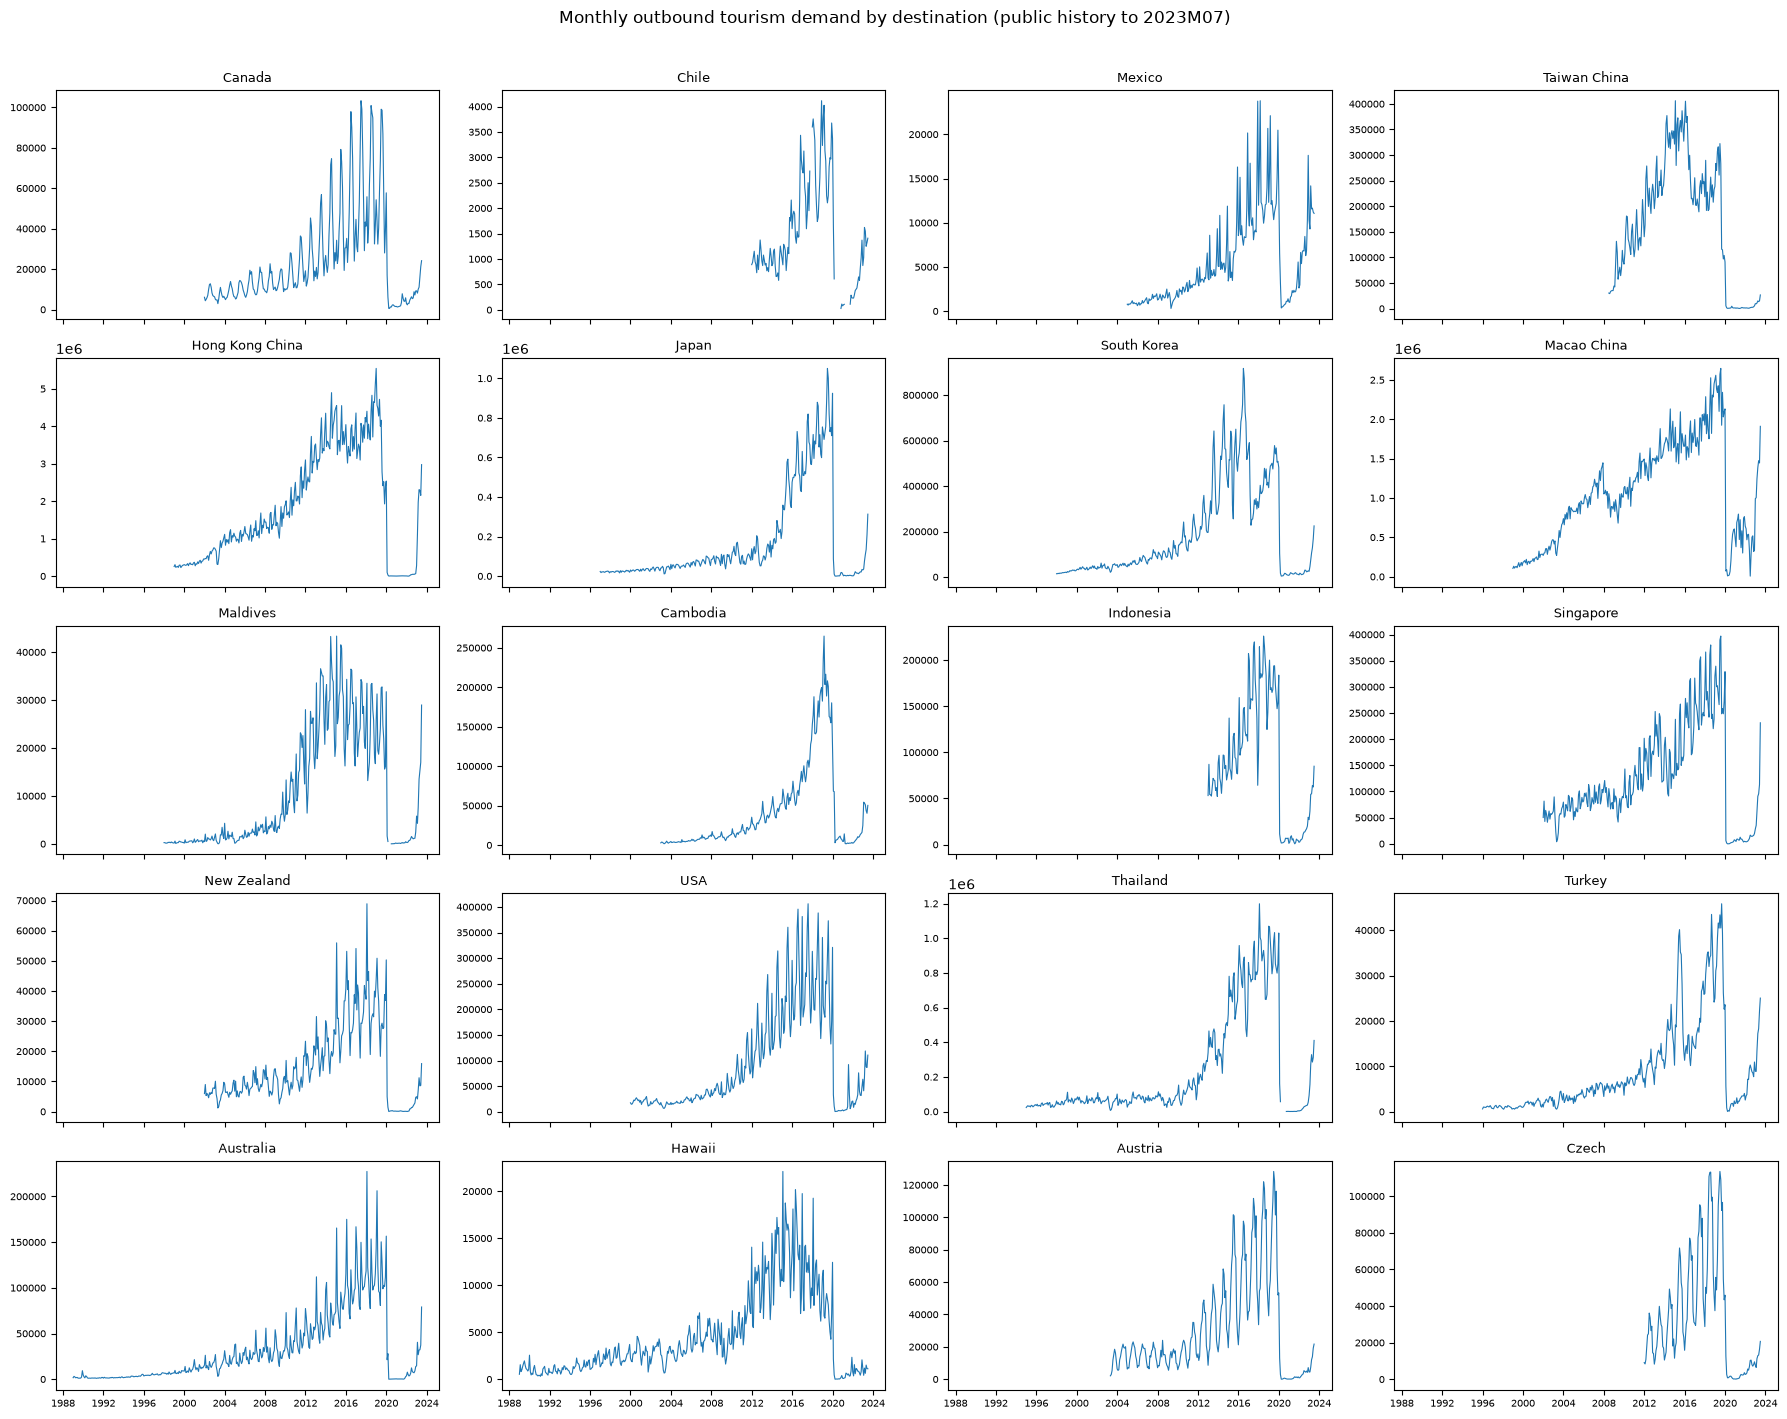

In [17]:
fig, axes = plt.subplots(5, 4, figsize=(18, 14), sharex=True)
for ax, destination in zip(axes.ravel(), REQUIRED_DESTINATIONS):
    dates = public_history_wide_to_2023M07[FINAL_FORECAST_DATE_COLUMN].map(
        month_label_to_period
    ).map(lambda period: period.to_timestamp())
    ax.plot(dates, public_history_wide_to_2023M07[destination], linewidth=0.8)
    ax.set_title(destination, fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle(
    "Monthly outbound tourism demand by destination (public history to 2023M07)",
    y=1.01,
)
fig.tight_layout()
plt.show()

**Summary of findings**

- Demand levels and starting dates vary greatly across destinations.
- Most destinations show a sharp decline around 2020 followed by an uneven recovery.
- Recurring peaks and troughs indicate seasonality in many series.
- The differences support destination-specific and recovery-aware forecasting models.

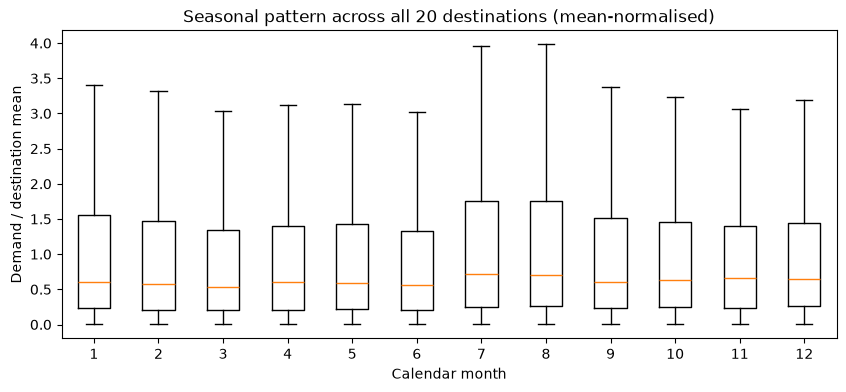

,destination,n_observations,adf_pvalue_level,adf_pvalue_first_difference,stationary_at_level,stationary_after_differencing
0,Canada,259,0.188,0.010,False,True
1,Chile,124,0.126,0.000,False,True
2,Mexico,223,0.299,0.007,False,True
3,Taiwan China,181,0.655,0.009,False,True
4,Hong Kong China,295,0.276,0.049,False,True
5,Japan,319,0.267,0.001,False,True
6,South Korea,307,0.311,0.000,False,True
7,Macao China,295,0.239,0.000,False,True
8,Maldives,304,0.401,0.030,False,True
9,Cambodia,247,0.149,0.003,False,True


Stationary at level (p<0.05): 0 / 20
Stationary after first differencing (p<0.05): 19 / 20


In [18]:
import warnings

from statsmodels.tsa.stattools import adfuller

# To check seasonality we normalise each destination by its own mean first -
# otherwise a plot mixing Hong Kong (millions) and Chile (thousands) is
# useless. Then we look at how normalised demand is spread out by calendar
# month across all 20 destinations.
normalised_demand = public_history_wide_to_2023M07[REQUIRED_DESTINATIONS].div(
    public_history_wide_to_2023M07[REQUIRED_DESTINATIONS].mean()
)
normalised_demand["_month"] = public_history_wide_to_2023M07[FINAL_FORECAST_DATE_COLUMN].map(
    lambda label: month_label_to_period(label).month
)
seasonal_boxplot_data = []
for calendar_month in range(1, 13):
    values = normalised_demand.loc[
        normalised_demand["_month"] == calendar_month, REQUIRED_DESTINATIONS
    ].to_numpy().ravel()
    seasonal_boxplot_data.append(values[~np.isnan(values)])

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(seasonal_boxplot_data, tick_labels=range(1, 13), showfliers=False)
ax.set_xlabel("Calendar month")
ax.set_ylabel("Demand / destination mean")
ax.set_title("Seasonal pattern across all 20 destinations (mean-normalised)")
plt.show()

# Now checking stationarity with an ADF test on both the raw level and the
# first-differenced series for each destination. If levels are non-stationary
# but the differences are, that's a good sign we should be differencing things
# rather than assuming a constant mean.
adf_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    for destination in REQUIRED_DESTINATIONS:
        level_series = public_history_wide_to_2023M07[destination].dropna()
        diff_series = level_series.diff().dropna()
        level_pvalue = adfuller(level_series, autolag="AIC")[1] if len(level_series) >= 24 else np.nan
        diff_pvalue = adfuller(diff_series, autolag="AIC")[1] if len(diff_series) >= 24 else np.nan
        adf_rows.append({
            "destination": destination,
            "n_observations": len(level_series),
            "adf_pvalue_level": level_pvalue,
            "adf_pvalue_first_difference": diff_pvalue,
            "stationary_at_level": (level_pvalue < 0.05) if pd.notna(level_pvalue) else None,
            "stationary_after_differencing": (diff_pvalue < 0.05) if pd.notna(diff_pvalue) else None,
        })
stationarity_summary = pd.DataFrame(adf_rows)
display(stationarity_summary.round(3))
print(
    "Stationary at level (p<0.05):",
    int(stationarity_summary["stationary_at_level"].sum()),
    "/", stationarity_summary["stationary_at_level"].notna().sum(),
)
print(
    "Stationary after first differencing (p<0.05):",
    int(stationarity_summary["stationary_after_differencing"].sum()),
    "/", stationarity_summary["stationary_after_differencing"].notna().sum(),
)

**Summary of table findings**

- None of the 20 destination series is stationary at level at the 5% significance level.
- After first differencing, 19 of the 20 series are stationary.
- Czech is the only series that remains non-stationary after first differencing (`p = 0.155`).
- Differencing is therefore appropriate for most series, with extra caution required for Czech.

**Summary of findings**

- Normalised demand changes across calendar months, showing an annual seasonal pattern.
- The spread differs by month, so seasonal strength is not the same for every destination.
- These findings support testing lag-12 and destination-level seasonal models.

In [19]:
# Flagging outlier months as anywhere the month-on-month % change has a
# z-score bigger than 3, worked out per destination so we're not just picking
# up the biggest-scale destinations by accident.
outlier_rows = []
for destination in REQUIRED_DESTINATIONS:
    pct_change = public_history_wide_to_2023M07[destination].pct_change()
    z_scores = (pct_change - pct_change.mean()) / pct_change.std()
    outlier_months = public_history_wide_to_2023M07.loc[
        z_scores.abs() > 3, FINAL_FORECAST_DATE_COLUMN
    ].tolist()
    outlier_rows.append({
        "destination": destination,
        "n_outlier_months": len(outlier_months),
        "outlier_months": outlier_months,
    })
outlier_summary = pd.DataFrame(outlier_rows).sort_values("n_outlier_months", ascending=False)
display(outlier_summary)


def _in_period_range(date_labels, start_label, end_label):
    periods = date_labels.map(month_label_to_period)
    return (periods >= month_label_to_period(start_label)) & (periods <= month_label_to_period(end_label))


# We already know COVID travel restrictions caused a huge break in this data,
# so let's actually measure it - comparing each destination's pre-COVID,
# COVID-trough, and most recent average to see how big the drop and recovery
# really are.
covid_windows = {
    "pre_covid_2017_2019": ("2017M01", "2019M12"),
    "covid_trough_2020_2021": ("2020M04", "2021M12"),
    "recovery_2022_2023": ("2022M06", "2023M07"),
}
covid_impact_rows = []
for destination in REQUIRED_DESTINATIONS:
    row = {"destination": destination}
    for label, (start, end) in covid_windows.items():
        mask = _in_period_range(public_history_wide_to_2023M07[FINAL_FORECAST_DATE_COLUMN], start, end)
        row[label] = public_history_wide_to_2023M07.loc[mask, destination].mean()
    row["covid_trough_pct_of_pre_covid"] = row["covid_trough_2020_2021"] / row["pre_covid_2017_2019"] * 100
    row["recovery_pct_of_pre_covid"] = row["recovery_2022_2023"] / row["pre_covid_2017_2019"] * 100
    covid_impact_rows.append(row)
covid_impact_summary = pd.DataFrame(covid_impact_rows).round(1)
display(covid_impact_summary)

,destination,n_outlier_months,outlier_months
17,Hawaii,9,"[1989M02, 1991M05, 1991M12, 2020M10, 2021M05, ..."
6,South Korea,7,"[2015M08, 2020M02, 2020M03, 2020M04, 2020M07, ..."
4,Hong Kong China,6,"[2020M09, 2022M04, 2022M05, 2022M06, 2023M01, ..."
9,Cambodia,6,"[2005M02, 2020M04, 2020M05, 2021M03, 2021M04, ..."
8,Maldives,5,"[2000M02, 2002M02, 2003M07, 2003M08, 2004M01]"
2,Mexico,4,"[2009M06, 2013M03, 2014M03, 2022M03]"
5,Japan,4,"[2020M06, 2020M10, 2020M11, 2022M03]"
16,Australia,4,"[1989M12, 2021M11, 2021M12, 2023M02]"
14,Thailand,4,"[2003M07, 2009M01, 2021M07, 2021M11]"
0,Canada,3,"[2020M04, 2020M06, 2021M08]"


,destination,pre_covid_2017_2019,covid_trough_2020_2021,recovery_2022_2023,covid_trough_pct_of_pre_covid,recovery_pct_of_pre_covid
0,Canada,59229.7,2539.8,10605.8,4.3,17.9
1,Chile,2783.5,133.4,1033.9,4.8,37.1
2,Mexico,13236.1,1696.5,10182.1,12.8,76.9
3,Taiwan China,226173.0,1246.7,8526.4,0.6,3.8
4,Hong Kong China,3868282.6,5056.0,959651.2,0.1,24.8
5,Japan,703617.9,4139.7,74519.2,0.6,10.6
6,South Korea,416163.5,12108.7,66864.7,2.9,16.1
7,Macao China,2093888.3,452669.9,840490.6,21.6,40.1
8,Maldives,24268.8,144.1,7293.8,0.6,30.1
9,Cambodia,155474.3,5510.3,28778.4,3.5,18.5


**Summary of table findings**

- Hawaii records the most flagged outlier months (`9`), followed by South Korea (`7`).
- Many outliers occur during the COVID-19 disruption and recovery, so they are more likely structural changes than data errors.
- Every destination's COVID-trough average is below 22% of its pre-COVID average.
- Recovery is uneven: Mexico reaches `76.9%` of its pre-COVID average, while Taiwan China reaches only `3.8%`.
- This uneven recovery supports recovery-aware, destination-specific forecasting.

<a id="eda-multivariate"></a>
#### Multivariate analysis

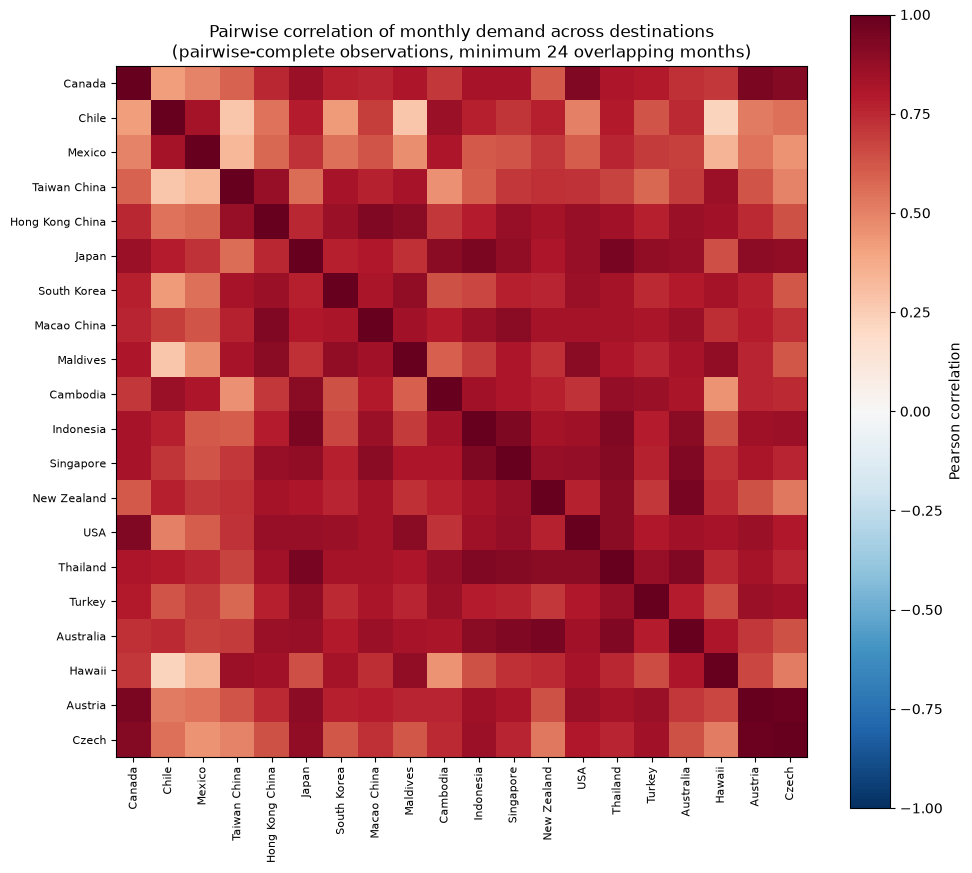

In [20]:
correlation_matrix = public_history_wide_to_2023M07[REQUIRED_DESTINATIONS].corr(min_periods=24)

fig, ax = plt.subplots(figsize=(10, 9))
heatmap = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(REQUIRED_DESTINATIONS)))
ax.set_xticklabels(REQUIRED_DESTINATIONS, rotation=90, fontsize=8)
ax.set_yticks(range(len(REQUIRED_DESTINATIONS)))
ax.set_yticklabels(REQUIRED_DESTINATIONS, fontsize=8)
ax.set_title(
    "Pairwise correlation of monthly demand across destinations\n"
    "(pairwise-complete observations, minimum 24 overlapping months)"
)
fig.colorbar(heatmap, ax=ax, label="Pearson correlation")
fig.tight_layout()
plt.show()

**Summary of findings**

- Most destinations are positively correlated because they experienced common tourism shocks.
- Australia is most strongly correlated with New Zealand (`r=0.95`).
- Japan has its weakest correlation with Taiwan China (`r=0.56`).
- The differing relationships support retaining destination-specific models.

Destinations ranked by correlation with Australia:


New Zealand        0.95
Singapore          0.93
Thailand           0.92
Indonesia          0.90
Japan              0.87
Hong Kong China    0.86
Macao China        0.86
USA                0.84
Maldives           0.82
Cambodia           0.82
Hawaii             0.81
South Korea        0.79
Turkey             0.79
Chile              0.75
Canada             0.73
Austria            0.71
Taiwan China       0.70
Mexico             0.68
Czech              0.64
Name: Australia, dtype: float64

Destinations ranked by correlation with Japan:


Thailand           0.95
Indonesia          0.94
Cambodia           0.90
Austria            0.90
Czech              0.89
Turkey             0.89
Singapore          0.88
USA                0.87
Australia          0.87
Canada             0.86
New Zealand        0.81
Macao China        0.80
Chile              0.78
South Korea        0.78
Hong Kong China    0.76
Maldives           0.73
Mexico             0.72
Hawaii             0.65
Taiwan China       0.56
Name: Japan, dtype: float64

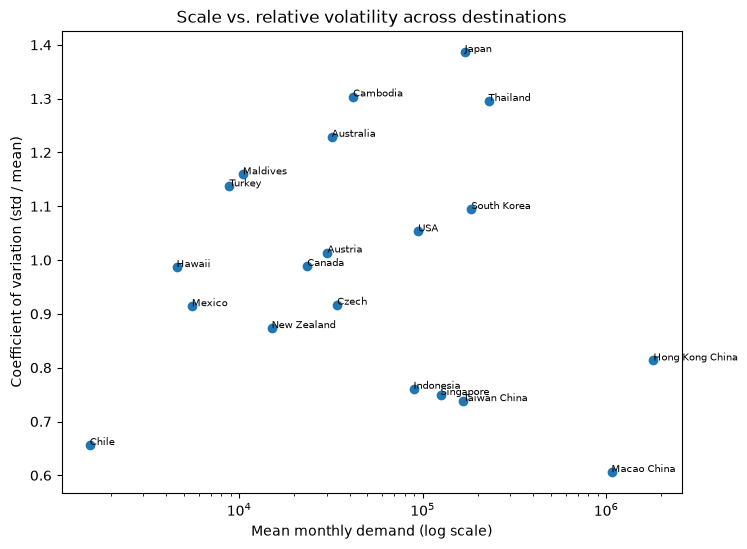

In [21]:
for destination in FOCUS_REQUIRED_DESTINATIONS:
    print(f"Destinations ranked by correlation with {destination}:")
    display(
        correlation_matrix[destination]
        .drop(destination)
        .sort_values(ascending=False)
        .round(2)
    )

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(destination_stats["mean"], destination_stats["cv"])
for destination in REQUIRED_DESTINATIONS:
    ax.annotate(
        destination,
        (destination_stats.loc[destination, "mean"], destination_stats.loc[destination, "cv"]),
        fontsize=7,
    )
ax.set_xscale("log")
ax.set_xlabel("Mean monthly demand (log scale)")
ax.set_ylabel("Coefficient of variation (std / mean)")
ax.set_title("Scale vs. relative volatility across destinations")
plt.show()

**Summary of table findings**

- New Zealand has the strongest correlation with Australia (`r = 0.95`).
- Thailand has the strongest correlation with Japan (`r = 0.95`).
- Czech has Australia's weakest listed correlation (`r = 0.64`).
- Taiwan China has Japan's weakest listed correlation (`r = 0.56`).
- New Zealand and Taiwan China therefore provide useful similar and contrasting markets for Q6.

**Summary of findings**

- Average demand varies greatly, from low-volume Chile to high-volume Hong Kong China and Macao China.
- Japan has the highest relative volatility, with a coefficient of variation near `1.4`.
- Macao China is less volatile relative to its mean, with a coefficient near `0.6`.
- Scale-free MASE is more suitable than raw MAE for comparing these destinations.

<a id="eda-findings"></a>
#### What we took away from the EDA

The main findings were:

- **History length varies.** Australia and Hawaii start at `1989M01`, while several series start much later. We kept pre-start values missing instead of filling them with zero.
- **Most distributions are right-skewed.** Taiwan China is close to symmetric, while Macao and Indonesia have only mild skew.
- **Levels are non-stationary.** None of the 20 level series pass the ADF test (Augmented Dickey–Fuller test), but 19 pass after first differencing.
- **COVID-19 is the main structural break.** Demand fell sharply in 2020-2021 and was still recovering at the final cutoff.
- **Most large outliers occur around COVID-19.** We therefore treat them as structural changes, not simple data errors.
- **Destinations are related but not identical.** This supports comparing both similar and contrasting markets in Q6.
- **Scale and volatility vary widely.** This supports using MASE rather than comparing destinations with raw MAE alone.

##### What is the ADF test, and why is it important?

- The Augmented Dickey–Fuller (ADF) test checks whether a time series is stationary, meaning its statistical behaviour is reasonably stable over time.
- Its null hypothesis is that the series has a unit root and is non-stationary. The alternative hypothesis is that the series is stationary.
- We use a 5% significance level. A p-value below `0.05` gives evidence to reject the null hypothesis; a larger p-value means there is not enough evidence to treat the series as stationary.
- This matters because models such as SARIMA work with stationary relationships. Testing both the original series and its first difference helps us decide whether differencing is needed.
- The ADF result is used together with the time-series plots because major structural changes, such as COVID-19, can affect the test.

In [22]:
# This is just the same cutoff-safe history from Part I and the EDA above,
# reshaped into long format (Date, destination, demand).
tourism_series_long = public_history_wide_to_2023M07.melt(
    id_vars=[FINAL_FORECAST_DATE_COLUMN],
    value_vars=REQUIRED_DESTINATIONS,
    var_name="destination",
    value_name="demand",
).rename(columns={FINAL_FORECAST_DATE_COLUMN: "Date"})
tourism_series_long = tourism_series_long.dropna(subset=["demand"]).reset_index(drop=True)

# We didn't use any external data, so this stays a zero-row table with just
# the required columns.
external_feature_log = pd.DataFrame(columns=EXTERNAL_FEATURE_LOG_COLUMNS)

display(tourism_series_long.head())
print("tourism_series_long shape:", tourism_series_long.shape)

,Date,destination,demand
0,2002M01,Canada,6088.0
1,2002M02,Canada,4356.0
2,2002M03,Canada,5008.0
3,2002M04,Canada,5841.0
4,2002M05,Canada,7042.0


tourism_series_long shape: (5362, 3)


<a id="model-naive-lag1"></a>
#### Model 1: Naive lag-1

- Uses the latest value available at the cutoff for every future month.
- Uses the required `generate_naive_forecast_wide(..., lag=1)` function defined in Q1.
- It is simple and stable, but its 12-month forecast is flat.
- Official validation: mean MASE **2.67** and mean MAPE **48.1%**.

<a id="model-naive-lag12"></a>
#### Model 2: Seasonal naive lag-12

- Uses the value from the same month one year earlier.
- Uses the required `generate_naive_forecast_wide(..., lag=12)` function defined in Q1.
- It keeps the seasonal pattern, but it misses the ongoing recovery.
- Official validation: mean MASE **4.41** and mean MAPE **77.9%**.

<a id="model-seasonal-recovery"></a>
#### Model 3: Seasonal recovery naive

The EDA showed seasonality, non-stationary levels, and an unfinished COVID-19 recovery. The two
baselines each miss part of this pattern:

- `naive_lag1` keeps the latest level but produces a flat 12-month forecast.
- `naive_lag12` keeps seasonality but ignores the recovery trend.

We therefore created `seasonal_recovery_naive`:

1. Start with the value from the same month one year earlier.
2. Calculate a recovery ratio from the latest six months and the same six months one year earlier.
3. Apply the ratio using only data available at the cutoff.
4. Reduce the ratio gradually across the forecast horizon.
5. Cap forecasts at 1.5 times the destination's historical maximum.

The method is deterministic, uses no optimiser, and works consistently across all destinations.
Official validation: mean MASE **2.70** and mean MAPE **45.4%**.

In [23]:
def _compute_recovery_ratio(
    historical_actual_wide,
    cutoff_label,
    destination,
    recovery_window=6,
    ratio_clip_bounds=(0.1, 10.0),
    date_column=FINAL_FORECAST_DATE_COLUMN,
):
    """Works out how much a destination has "recovered" recently.

    Compares the average of the last `recovery_window` months to the same
    months one year earlier, using only actuals at or before `cutoff_label`.
    Returns 1.0 (i.e. no adjustment) if we can't compute it properly, and
    clips silly extreme ratios so one weird destination can't dominate.
    """
    cutoff_period = _month_label_to_period(cutoff_label)
    history = historical_actual_wide.copy()
    history["_period"] = history[date_column].map(_month_label_to_period)
    history = history[history["_period"] <= cutoff_period].sort_values("_period")

    series = history.set_index("_period")[destination]
    valid = series.dropna()
    if len(valid) == 0:
        return 1.0

    # Compare like-for-like calendar months so the ratio measures recovery
    # in level without confusing it with ordinary annual seasonality.
    recent_window = valid.iloc[-recovery_window:]
    recent_level = recent_window.mean()
    year_ago_periods = [period - 12 for period in recent_window.index]
    year_ago_level = series.reindex(year_ago_periods).mean()

    if pd.notna(year_ago_level) and year_ago_level > 0:
        ratio = recent_level / year_ago_level
    else:
        ratio = 1.0
    # Clipping is a stability guard for destinations rebounding from a very
    # small year-ago base, where the raw ratio can otherwise become extreme.
    return float(np.clip(ratio, *ratio_clip_bounds))


def _historical_growth_cap(history_wide, destination, max_growth_multiple=1.5):
    """Shared sanity-check cap: no candidate model here is allowed to forecast
    more than `max_growth_multiple` times a destination's own cutoff-safe
    historical maximum. `history_wide` must already be trimmed to the cutoff.
    Used by seasonal_recovery_naive, sarima, and prophet below so a
    fast-reopening destination (e.g. Hong Kong China, Macao China) can't blow
    up in any of them.
    """
    historical_max = history_wide[destination].max()
    return max_growth_multiple * historical_max if pd.notna(historical_max) else np.inf


def generate_seasonal_recovery_forecast_wide(
    historical_actual_wide,
    cutoff_label,
    forecast_months,
    required_destinations=None,
    date_column=FINAL_FORECAST_DATE_COLUMN,
    recovery_window=6,
    decay_horizon=12,
    ratio_clip_bounds=(0.1, 10.0),
    max_growth_multiple=1.5,
):
    """Generate a seasonal forecast adjusted for recent demand recovery.

    This model begins with the value from the same month one year earlier, which
    preserves annual seasonality. For each destination it also compares the most
    recent observations with their year-earlier counterparts to estimate a recovery
    ratio. That adjustment is strongest at the start of the forecast and gradually
    decays toward an ordinary seasonal-naive forecast over `decay_horizon` months.

    All calculations use history at or before the cutoff. Recovery ratios are clipped
    to avoid unstable scaling, unavailable seasonal values fall back to the latest
    valid observation, and forecasts are capped relative to the historical maximum.
    The returned DataFrame follows the same wide-table contract as the naive model,
    allowing it to pass directly into the validation and evaluation functions.
    """
    if required_destinations is None:
        required_destinations = [
            column for column in historical_actual_wide.columns if column != date_column
        ]

    cutoff_period = _month_label_to_period(cutoff_label)
    history = historical_actual_wide.copy()
    history["_period"] = history[date_column].map(_month_label_to_period)
    history = history[history["_period"] <= cutoff_period].sort_values("_period")

    # Pre-compute destination-specific ratios and caps once; the forecast
    # loop can then apply the same transparent rules to every horizon step.
    recovery_ratios = {
        destination: _compute_recovery_ratio(
            historical_actual_wide, cutoff_label, destination, recovery_window,
            ratio_clip_bounds, date_column,
        )
        for destination in required_destinations
    }
    historical_growth_caps = {
        destination: _historical_growth_cap(history, destination, max_growth_multiple)
        for destination in required_destinations
    }

    rows = []
    for step, month_label in enumerate(forecast_months):
        row = {date_column: month_label}
        target_period = _month_label_to_period(month_label)
        # The recovery adjustment is strongest near the cutoff and gradually
        # returns to an ordinary seasonal-naive forecast over the horizon.
        decay_weight = max(0.0, 1.0 - step / decay_horizon)
        for destination in required_destinations:
            series = history.set_index("_period")[destination]
            source_value = series.get(target_period - 12, np.nan)
            if pd.isna(source_value):
                # If there's no value from 12 months ago yet (happens for destinations
                # with under a year of history), just carry forward the last value we
                # actually have.
                valid = series.dropna()
                source_value = valid.iloc[-1] if len(valid) else np.nan

            applied_ratio = 1.0 + (recovery_ratios[destination] - 1.0) * decay_weight
            forecast_value = source_value * applied_ratio if pd.notna(source_value) else np.nan
            if pd.notna(forecast_value):
                forecast_value = min(forecast_value, historical_growth_caps[destination])
            row[destination] = forecast_value
        rows.append(row)

    return pd.DataFrame(rows, columns=[date_column] + required_destinations)

<a id="model-blended-recovery"></a>
#### Model 4: Blended recovery

- Combines 60% naive lag-1 with 40% seasonal recovery.
- The lag-1 part controls extreme values, while the recovery part keeps some seasonal shape.
- It is the selected model because it has the best official mean MASE (**2.49**) and MAPE (**43.0%**).

In [24]:
# Use 40% seasonal-recovery and 60% lag-1: this fixed weight keeps useful
# recovery/seasonal movement while the larger lag-1 share limits extreme
# forecasts. It produced the best aggregate MASE and MAPE in the official
# validation window; it is a validation-supported trade-off, not the result
# of a continuous or exhaustive weight-optimisation search.
BLENDED_RECOVERY_WEIGHT = 0.4


def generate_blended_recovery_forecast_wide(
    historical_actual_wide,
    cutoff_label,
    forecast_months,
    required_destinations=None,
    date_column=FINAL_FORECAST_DATE_COLUMN,
    recovery_weight=BLENDED_RECOVERY_WEIGHT,
):
    """Blend a stable lag-one forecast with the seasonal recovery forecast.

    The lag-one component carries the latest known level forward, while the recovery
    component contributes annual seasonal shape and post-disruption movement. The
    `recovery_weight` controls this trade-off: zero gives only lag one, one gives only
    seasonal recovery, and the default 0.4 assigns 60 percent to stability and 40
    percent to recovery.

    Both component forecasts are generated from cutoff-safe data before their
    destination values are combined. The method is deterministic, rejects weights
    outside zero to one, and preserves the requested dates and wide-column order.
    """
    if not 0 <= recovery_weight <= 1:
        raise ValueError("recovery_weight must be between 0 and 1")
    if required_destinations is None:
        required_destinations = [
            column for column in historical_actual_wide.columns if column != date_column
        ]

    # Generate both components from the identical cutoff-safe history before
    # combining them; neither component can see future actual values.
    lag1 = generate_naive_forecast_wide(
        historical_actual_wide, cutoff_label, forecast_months,
        required_destinations, lag=1, date_column=date_column,
    )
    recovery = generate_seasonal_recovery_forecast_wide(
        historical_actual_wide, cutoff_label, forecast_months,
        required_destinations, date_column=date_column,
    )
    # Blend only destination values, leaving Date and column order untouched.
    blended = lag1.copy()
    blended[required_destinations] = (
        (1.0 - recovery_weight) * lag1[required_destinations]
        + recovery_weight * recovery[required_destinations]
    )
    return blended[[date_column] + required_destinations]

#### Shared setup for Models 5-7

- All models use data only up to `cutoff_label`.
- Each model uses the same fixed settings for every destination.
- SARIMA and Prophet require 36 observations and fall back to `seasonal_recovery_naive` if fitting fails;
- TimesFM falls back to `blended_recovery` if loading or prediction fails; and
- model forecasts are floored at zero and use the shared historical growth cap.
- We did not add a COVID-19 dummy, so the models handle the structural break without a manual intervention.

In [25]:
# Prophet isn't part of the project's base dependencies (see pyproject.toml);
# this installs it if it's missing (e.g. a fresh Colab runtime). For local
# runs we've already pinned it with `uv add prophet` -> uv.lock, alongside the
# statsmodels dependency that was already there for SARIMAX/adfuller.
try:
    import prophet  # noqa: F401
except ImportError:
    %pip install -q prophet

# TimesFM is pinned in pyproject.toml/uv.lock for local runs.
try:
    import timesfm  # noqa: F401
except ImportError:
    %pip install -q "timesfm[torch]==2.0.2"

/opt/project/training/ml-deakin/Tri-Mester-2/EndTerm-Task/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [26]:
import logging
import os

import timesfm
import torch
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet/cmdstanpy print a lot of fit-progress noise by default (and don't
# respect logging.setLevel() for it - only .disabled actually silences it);
# quiet it down so it doesn't bury the validation/backtest output below.
logging.getLogger("cmdstanpy").disabled = True
logging.getLogger("prophet").disabled = True

# Minimum months of history required before we even attempt a SARIMA/Prophet
# fit for a destination; below this we go straight to the
# seasonal_recovery_naive fallback. Roughly 3 full seasonal cycles, which is
# what SARIMA's seasonal_order with m=12 needs to be meaningfully identifiable.
SARIMA_PROPHET_MIN_HISTORY_MONTHS = 36


<a id="model-sarima"></a>
#### Model 5: SARIMA

- Uses a fixed SARIMA `(1,1,1)(1,1,1,12)` setup for each destination.
- It models differencing, autocorrelation, and yearly seasonality.
- Official validation: mean MASE **2.98** and mean MAPE **54.9%**.

In [27]:
def generate_sarima_forecast_wide(
    historical_actual_wide,
    cutoff_label,
    forecast_months,
    required_destinations=None,
    date_column=FINAL_FORECAST_DATE_COLUMN,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    min_history_months=SARIMA_PROPHET_MIN_HISTORY_MONTHS,
    max_growth_multiple=1.5,
    fallback_generator=generate_seasonal_recovery_forecast_wide,
    diagnostic_log=None,
):
    """Generate independent fixed-order SARIMA forecasts for each destination.

    By default, each cutoff-safe series is fitted with SARIMAX(1,1,1)(1,1,1,12).
    The non-seasonal terms model short-run dependence and change, while the seasonal
    terms represent a repeating twelve-month cycle. Fixed orders are shared across
    destinations so the comparison is reproducible and does not hide an additional
    destination-specific tuning search.

    Forecast months must be consecutive and immediately follow the cutoff. A series
    with too little usable history, a fitting failure, or a non-finite prediction uses
    `fallback_generator` instead, without stopping other destinations. Successful
    predictions are restricted to nonnegative, historically plausible values. When
    supplied, `diagnostic_log` records the fallback destinations for transparent
    reporting, while the return value keeps the standard wide-table shape.
    """
    if required_destinations is None:
        required_destinations = [
            column for column in historical_actual_wide.columns if column != date_column
        ]

    cutoff_period = _month_label_to_period(cutoff_label)
    forecast_periods = [_month_label_to_period(month) for month in forecast_months]
    expected_periods = [cutoff_period + step for step in range(1, len(forecast_periods) + 1)]
    if forecast_periods != expected_periods:
        raise ValueError(
            "generate_sarima_forecast_wide only supports forecast_months that "
            "are consecutive months immediately after cutoff_label."
        )

    history = historical_actual_wide.copy()
    history["_period"] = history[date_column].map(_month_label_to_period)
    history = history[history["_period"] <= cutoff_period].sort_values("_period")

    # Build the fallback up front so one failed destination fit cannot stop
    # the all-20 forecast table from being produced.
    fallback_wide = fallback_generator(
        historical_actual_wide,
        cutoff_label=cutoff_label,
        forecast_months=forecast_months,
        required_destinations=required_destinations,
        date_column=date_column,
    ).set_index(date_column)

    fallback_destinations = []
    forecasts_by_destination = {}
    for destination in required_destinations:
        series = history.set_index("_period")[destination]
        valid = series.dropna()
        # Three seasonal cycles are required before attempting this fitted
        # model; shorter histories use the deterministic fallback directly.
        use_fallback = len(valid) < min_history_months
        forecast_values = None

        if not use_fallback:
            try:
                series_from_start = series.loc[valid.index.min():].asfreq("M")
                fitted = SARIMAX(
                    series_from_start,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False)
                forecast_values = fitted.get_forecast(steps=len(forecast_periods)).predicted_mean.to_numpy()
                if not np.all(np.isfinite(forecast_values)):
                    use_fallback = True
            except Exception:
                use_fallback = True

        # Fit failures and non-finite forecasts are recorded rather than
        # silently dropping the destination from the final wide table.
        if use_fallback:
            fallback_destinations.append(destination)
            forecast_values = fallback_wide[destination].to_numpy()
        else:
            growth_cap = _historical_growth_cap(history, destination, max_growth_multiple)
            forecast_values = np.clip(forecast_values, 0, growth_cap)

        forecasts_by_destination[destination] = forecast_values

    if diagnostic_log is not None:
        diagnostic_log["fallback_destinations"] = fallback_destinations

    rows = []
    for step, month_label in enumerate(forecast_months):
        row = {date_column: month_label}
        for destination in required_destinations:
            row[destination] = forecasts_by_destination[destination][step]
        rows.append(row)

    return pd.DataFrame(rows, columns=[date_column] + required_destinations)

<a id="model-prophet"></a>
#### Model 6: Prophet

- Uses yearly multiplicative seasonality and trend changepoints.
- The same fixed settings are used for every destination.
- Official validation: mean MASE **4.23** and mean MAPE **83.8%**.

In [28]:
def generate_prophet_forecast_wide(
    historical_actual_wide,
    cutoff_label,
    forecast_months,
    required_destinations=None,
    date_column=FINAL_FORECAST_DATE_COLUMN,
    min_history_months=SARIMA_PROPHET_MIN_HISTORY_MONTHS,
    max_growth_multiple=1.5,
    fallback_generator=generate_seasonal_recovery_forecast_wide,
    diagnostic_log=None,
):
    """Generate an independent Prophet forecast for each destination.

    Prophet separates each cutoff-safe series into a flexible trend and recurring
    yearly seasonal effects. Weekly and daily seasonality are disabled because the
    observations are monthly, while multiplicative seasonality lets the size of the
    seasonal pattern change with the demand level. Fixed settings and MAP estimation
    are used for every destination to keep the comparison repeatable.

    Forecast months must be consecutive and immediately follow the cutoff. If there
    are fewer than `min_history_months` valid observations, fitting fails, or Prophet
    returns a non-finite value, that destination uses `fallback_generator`. Successful
    predictions are floored at zero and capped relative to cutoff-safe history. An
    optional diagnostic dictionary records fallback destinations without changing the
    standard wide-format return table.
    """
    if required_destinations is None:
        required_destinations = [
            column for column in historical_actual_wide.columns if column != date_column
        ]

    cutoff_period = _month_label_to_period(cutoff_label)
    forecast_periods = [_month_label_to_period(month) for month in forecast_months]
    expected_periods = [cutoff_period + step for step in range(1, len(forecast_periods) + 1)]
    if forecast_periods != expected_periods:
        raise ValueError(
            "generate_prophet_forecast_wide only supports forecast_months that "
            "are consecutive months immediately after cutoff_label."
        )

    history = historical_actual_wide.copy()
    history["_period"] = history[date_column].map(_month_label_to_period)
    history = history[history["_period"] <= cutoff_period].sort_values("_period")

    fallback_wide = fallback_generator(
        historical_actual_wide,
        cutoff_label=cutoff_label,
        forecast_months=forecast_months,
        required_destinations=required_destinations,
        date_column=date_column,
    ).set_index(date_column)

    # Prophet expects real timestamps rather than the YYYYMmm labels used by
    # the assignment, so convert only after cutoff checks are complete.
    future_timestamps = [period.to_timestamp() for period in forecast_periods]

    fallback_destinations = []
    forecasts_by_destination = {}
    for destination in required_destinations:
        series = history.set_index("_period")[destination]
        valid = series.dropna()
        use_fallback = len(valid) < min_history_months
        forecast_values = None

        if not use_fallback:
            try:
                fit_df = pd.DataFrame({
                    "ds": [period.to_timestamp() for period in valid.index],
                    "y": valid.to_numpy(),
                })
                # Disable daily/weekly effects because the source data are
                # monthly; retain yearly seasonality with fixed settings.
                model = Prophet(
                    yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    seasonality_mode="multiplicative",
                    mcmc_samples=0,
                )
                model.fit(fit_df)
                future = pd.DataFrame({"ds": future_timestamps})
                forecast_values = model.predict(future)["yhat"].to_numpy()
                if not np.all(np.isfinite(forecast_values)):
                    use_fallback = True
            except Exception:
                use_fallback = True

        if use_fallback:
            fallback_destinations.append(destination)
            forecast_values = fallback_wide[destination].to_numpy()
        else:
            growth_cap = _historical_growth_cap(history, destination, max_growth_multiple)
            forecast_values = np.clip(forecast_values, 0, growth_cap)

        forecasts_by_destination[destination] = forecast_values

    if diagnostic_log is not None:
        diagnostic_log["fallback_destinations"] = fallback_destinations

    rows = []
    for step, month_label in enumerate(forecast_months):
        row = {date_column: month_label}
        for destination in required_destinations:
            row[destination] = forecasts_by_destination[destination][step]
        rows.append(row)

    return pd.DataFrame(rows, columns=[date_column] + required_destinations)

<a id="model-timesfm"></a>
#### Model 7: TimesFM 2.5

- Uses a pretrained time-series foundation model in zero-shot mode.
- It is not fitted or fine-tuned using this dataset.
- It uses the pinned `google/timesfm-2.5-200m-pytorch` checkpoint with a 512-month context.
- Official validation: mean MASE **2.60** and mean MAPE **43.8%**.
- It has the best 12-month recovery-backtest MASE: **2.06**.

In [29]:
TIMESFM_MODEL_ID = "google/timesfm-2.5-200m-pytorch"
TIMESFM_CACHE_DIR = os.environ.get(
    "TIMESFM_CACHE_DIR", str(Path(".cache") / "timesfm")
)
_timesfm_model = None


def _get_timesfm_model():
    """Load and compile the pinned TimesFM checkpoint once per runtime."""
    global _timesfm_model
    # Lazy loading avoids downloading and compiling the checkpoint until a
    # TimesFM forecast is actually requested, then reuses it in this runtime.
    if _timesfm_model is None:
        torch.set_float32_matmul_precision("high")
        _timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
            TIMESFM_MODEL_ID, cache_dir=TIMESFM_CACHE_DIR
        )
        _timesfm_model.compile(
            timesfm.ForecastConfig(
                max_context=512,
                max_horizon=12,
                normalize_inputs=True,
                per_core_batch_size=20,
                use_continuous_quantile_head=True,
                force_flip_invariance=True,
                infer_is_positive=True,
                fix_quantile_crossing=True,
            )
        )
    return _timesfm_model


def generate_timesfm_forecast_wide(
    historical_actual_wide,
    cutoff_label,
    forecast_months,
    required_destinations=None,
    date_column=FINAL_FORECAST_DATE_COLUMN,
    max_growth_multiple=1.5,
    fallback_generator=generate_blended_recovery_forecast_wide,
    diagnostic_log=None,
):
    """Generate cutoff-safe zero-shot forecasts with the pinned TimesFM model.

    TimesFM is a pretrained time-series foundation model, so this function supplies
    each destination's available history as context without fitting or fine-tuning a
    local model. Valid histories are converted to float32 and forecast together in one
    batch; the model checkpoint is loaded and compiled once, then reused in the runtime.

    Requested months must be consecutive and immediately follow the cutoff. A destination
    with no history, a non-finite prediction, or a model-loading or batch-inference error
    uses the blended-recovery fallback. Valid predictions are floored at zero and capped
    relative to historical demand. The optional diagnostic log records the model ID,
    fallback destinations, and any exception, while the returned DataFrame preserves the
    same date-first wide format used throughout the workflow.
    """
    if required_destinations is None:
        required_destinations = [
            column for column in historical_actual_wide.columns if column != date_column
        ]

    cutoff_period = _month_label_to_period(cutoff_label)
    forecast_periods = [_month_label_to_period(month) for month in forecast_months]
    expected_periods = [cutoff_period + step for step in range(1, len(forecast_periods) + 1)]
    if forecast_periods != expected_periods:
        raise ValueError(
            "generate_timesfm_forecast_wide requires consecutive months immediately after the cutoff"
        )

    history = historical_actual_wide.copy()
    history["_period"] = history[date_column].map(_month_label_to_period)
    history = history[history["_period"] <= cutoff_period].sort_values("_period")
    fallback_wide = fallback_generator(
        historical_actual_wide, cutoff_label, forecast_months,
        required_destinations, date_column=date_column,
    ).set_index(date_column)

    # TimesFM accepts one variable-length context array per destination; keep
    # a parallel destination list so batch outputs map back correctly.
    model_inputs = []
    model_destinations = []
    fallback_destinations = []
    for destination in required_destinations:
        values = history[destination].dropna().to_numpy(dtype=np.float32)
        if len(values) == 0:
            fallback_destinations.append(destination)
        else:
            model_inputs.append(values)
            model_destinations.append(destination)

    forecasts = {
        destination: fallback_wide[destination].to_numpy(dtype=float)
        for destination in fallback_destinations
    }
    # Treat the external checkpoint as optional: any loading or inference
    # failure falls back to the deterministic blended-recovery forecast.
    try:
        if model_inputs:
            point_forecasts, _ = _get_timesfm_model().forecast(
                horizon=len(forecast_months), inputs=model_inputs
            )
            for index, destination in enumerate(model_destinations):
                values = np.asarray(point_forecasts[index], dtype=float)
                if not np.all(np.isfinite(values)):
                    fallback_destinations.append(destination)
                    values = fallback_wide[destination].to_numpy(dtype=float)
                growth_cap = _historical_growth_cap(history, destination, max_growth_multiple)
                forecasts[destination] = np.clip(values, 0, growth_cap)
    except Exception as error:
        fallback_destinations.extend(
            destination for destination in model_destinations
            if destination not in fallback_destinations
        )
        forecasts.update({
            destination: fallback_wide[destination].to_numpy(dtype=float)
            for destination in model_destinations
        })
        if diagnostic_log is not None:
            diagnostic_log["error"] = str(error)

    if diagnostic_log is not None:
        diagnostic_log["fallback_destinations"] = sorted(set(fallback_destinations))
        diagnostic_log["model_id"] = TIMESFM_MODEL_ID

    rows = []
    for step, month_label in enumerate(forecast_months):
        row = {date_column: month_label}
        row.update({destination: forecasts[destination][step] for destination in required_destinations})
        rows.append(row)
    return pd.DataFrame(rows, columns=[date_column] + required_destinations)

In [30]:
# This table shows what each candidate model actually has to work with per
# destination - at both the validation cutoff (2023M02) and the final cutoff
# (2023M07) - so it's still something a marker (or us) can go and inspect,
# even though seasonal_recovery_naive/sarima/prophet aren't classic
# tabular-feature models.
modelling_data_or_feature_table = pd.DataFrame({
    "destination": REQUIRED_DESTINATIONS,
    "n_observations_at_validation_cutoff": [
        training_actual_wide_to_2023M02[destination].notna().sum()
        for destination in REQUIRED_DESTINATIONS
    ],
    "n_observations_at_final_cutoff": [
        public_history_wide_to_2023M07[destination].notna().sum()
        for destination in REQUIRED_DESTINATIONS
    ],
    "recovery_ratio_at_validation_cutoff": [
        _compute_recovery_ratio(training_actual_wide_to_2023M02, TRAIN_END, destination)
        for destination in REQUIRED_DESTINATIONS
    ],
    "recovery_ratio_at_final_cutoff": [
        _compute_recovery_ratio(public_history_wide_to_2023M07, "2023M07", destination)
        for destination in REQUIRED_DESTINATIONS
    ],
})

# Whether each destination has enough history for us to even attempt a
# SARIMA/Prophet fit (see SARIMA_PROPHET_MIN_HISTORY_MONTHS above), or
# whether it's expected to fall back to seasonal_recovery_naive instead.
modelling_data_or_feature_table["sarima_prophet_eligible_at_validation_cutoff"] = (
    modelling_data_or_feature_table["n_observations_at_validation_cutoff"]
    >= SARIMA_PROPHET_MIN_HISTORY_MONTHS
)
modelling_data_or_feature_table["sarima_prophet_eligible_at_final_cutoff"] = (
    modelling_data_or_feature_table["n_observations_at_final_cutoff"]
    >= SARIMA_PROPHET_MIN_HISTORY_MONTHS
)

modelling_data_or_feature_table = modelling_data_or_feature_table.merge(
    destination_stats[["cv"]].rename(columns={"cv": "coefficient_of_variation"}),
    left_on="destination", right_index=True,
)
display(modelling_data_or_feature_table.round(2))

,destination,n_observations_at_validation_cutoff,n_observations_at_final_cutoff,recovery_ratio_at_validation_cutoff,recovery_ratio_at_final_cutoff,sarima_prophet_eligible_at_validation_cutoff,sarima_prophet_eligible_at_final_cutoff,coefficient_of_variation
0,Canada,254,259,1.95,3.66,True,True,0.99
1,Chile,119,124,4.31,3.60,True,True,0.66
2,Mexico,218,223,3.08,1.95,True,True,0.91
3,Taiwan China,176,181,3.74,10.00,True,True,0.74
4,Hong Kong China,290,295,10.00,10.00,True,True,0.81
5,Japan,314,319,9.60,10.00,True,True,1.39
6,South Korea,302,307,2.09,8.93,True,True,1.09
7,Macao China,290,295,1.01,3.39,True,True,0.61
8,Maldives,299,304,9.70,10.00,True,True,1.16
9,Cambodia,242,247,8.12,7.54,True,True,1.30


<a id="model-validation"></a>
#### Validation: all seven candidate models

In [31]:
seasonal_recovery_validation_forecast_wide = generate_seasonal_recovery_forecast_wide(
    training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)

seasonal_recovery_validation_audit = validate_forecast_actual_wide(
    seasonal_recovery_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
assert seasonal_recovery_validation_audit["can_align"] is True
assert seasonal_recovery_validation_audit["is_valid"] is True

seasonal_recovery_destination_metrics, seasonal_recovery_aggregate_metrics = evaluate_forecast_wide(
    seasonal_recovery_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
)

print("naive_lag1          :", baseline_lag1_aggregate_metrics)
print("naive_lag12         :", baseline_lag12_aggregate_metrics)
print("seasonal_recovery_naive:", seasonal_recovery_aggregate_metrics)

blended_recovery_validation_forecast_wide = generate_blended_recovery_forecast_wide(
    training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
blended_recovery_validation_audit = validate_forecast_actual_wide(
    blended_recovery_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
assert blended_recovery_validation_audit["is_valid"] is True
blended_recovery_destination_metrics, blended_recovery_aggregate_metrics = evaluate_forecast_wide(
    blended_recovery_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
)
print("blended_recovery       :", blended_recovery_aggregate_metrics)

naive_lag1          : {'n_destinations': 20, 'mean_mase': 2.6706784523596956, 'median_mase': 1.6963719005002749, 'mean_mape': 48.057644590753156}
naive_lag12         : {'n_destinations': 20, 'mean_mase': 4.409590680755385, 'median_mase': 3.8286562961778934, 'mean_mape': 77.89872819510933}
seasonal_recovery_naive: {'n_destinations': 20, 'mean_mase': 2.70024702714956, 'median_mase': 1.62351068761079, 'mean_mape': 45.42791448302359}
blended_recovery       : {'n_destinations': 20, 'mean_mase': 2.486685405712792, 'median_mase': 1.5317977269608056, 'mean_mape': 42.979365297983236}


In [32]:
sarima_validation_diagnostics = {}
sarima_validation_forecast_wide = generate_sarima_forecast_wide(
    training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    diagnostic_log=sarima_validation_diagnostics,
)

sarima_validation_audit = validate_forecast_actual_wide(
    sarima_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
assert sarima_validation_audit["can_align"] is True
assert sarima_validation_audit["is_valid"] is True

sarima_destination_metrics, sarima_aggregate_metrics = evaluate_forecast_wide(
    sarima_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
)

print("sarima validation fallbacks:", sarima_validation_diagnostics["fallback_destinations"])
print("sarima                  :", sarima_aggregate_metrics)

sarima validation fallbacks: []
sarima                  : {'n_destinations': 20, 'mean_mase': 2.9821700390872214, 'median_mase': 2.776553093398431, 'mean_mape': 54.931501618684436}


In [33]:
prophet_validation_diagnostics = {}
prophet_validation_forecast_wide = generate_prophet_forecast_wide(
    training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    diagnostic_log=prophet_validation_diagnostics,
)

prophet_validation_audit = validate_forecast_actual_wide(
    prophet_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
assert prophet_validation_audit["can_align"] is True
assert prophet_validation_audit["is_valid"] is True

prophet_destination_metrics, prophet_aggregate_metrics = evaluate_forecast_wide(
    prophet_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
)

print("prophet validation fallbacks:", prophet_validation_diagnostics["fallback_destinations"])
print("prophet                 :", prophet_aggregate_metrics)

timesfm_validation_diagnostics = {}
timesfm_validation_forecast_wide = generate_timesfm_forecast_wide(
    training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    diagnostic_log=timesfm_validation_diagnostics,
)
timesfm_validation_audit = validate_forecast_actual_wide(
    timesfm_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
assert timesfm_validation_audit["is_valid"] is True
timesfm_destination_metrics, timesfm_aggregate_metrics = evaluate_forecast_wide(
    timesfm_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
)
print("timesfm validation fallbacks:", timesfm_validation_diagnostics["fallback_destinations"])
print("timesfm                 :", timesfm_aggregate_metrics)

prophet validation fallbacks: []
prophet                 : {'n_destinations': 20, 'mean_mase': 4.2341581958881935, 'median_mase': 3.7487006665493032, 'mean_mape': 83.75733594021315}


timesfm validation fallbacks: []
timesfm                 : {'n_destinations': 20, 'mean_mase': 2.5994342165358284, 'median_mase': 1.9968982753936722, 'mean_mape': 43.79249222665232}


In [34]:
# Quick at-a-glance comparison of all seven candidates on the official
# validation window - not a required object, just supporting evidence for Q4.
validation_model_comparison = pd.DataFrame([
    {"model_label": "naive_lag1", **baseline_lag1_aggregate_metrics},
    {"model_label": "naive_lag12", **baseline_lag12_aggregate_metrics},
    {"model_label": "seasonal_recovery_naive", **seasonal_recovery_aggregate_metrics},
    {"model_label": "blended_recovery", **blended_recovery_aggregate_metrics},
    {"model_label": "sarima", **sarima_aggregate_metrics},
    {"model_label": "prophet", **prophet_aggregate_metrics},
    {"model_label": "timesfm_2p5_zero_shot", **timesfm_aggregate_metrics},
]).sort_values("mean_mase").reset_index(drop=True)

display(validation_model_comparison.round(2))

,model_label,n_destinations,mean_mase,median_mase,mean_mape
0,blended_recovery,20,2.49,1.53,42.98
1,timesfm_2p5_zero_shot,20,2.60,2.00,43.79
2,naive_lag1,20,2.67,1.70,48.06
3,seasonal_recovery_naive,20,2.70,1.62,45.43
4,sarima,20,2.98,2.78,54.93
5,prophet,20,4.23,3.75,83.76
6,naive_lag12,20,4.41,3.83,77.90


In [35]:
def _wide_forecast_to_long(forecast_wide_df, model_label, date_column=FINAL_FORECAST_DATE_COLUMN):
    # Convert each model's assignment-format wide table into one standard
    # long table so models can be filtered and compared consistently.
    long_df = forecast_wide_df.melt(
        id_vars=[date_column], var_name="destination", value_name="forecast"
    )
    long_df.insert(0, "model_label", model_label)
    return long_df.rename(columns={date_column: "Date"})[VALIDATION_FORECAST_COLUMNS]


# Stack every candidate using the same column contract and validation months.
validation_forecasts = pd.concat(
    [
        _wide_forecast_to_long(baseline_lag1_validation_forecast_wide, "naive_lag1"),
        _wide_forecast_to_long(baseline_lag12_validation_forecast_wide, "naive_lag12"),
        _wide_forecast_to_long(seasonal_recovery_validation_forecast_wide, "seasonal_recovery_naive"),
        _wide_forecast_to_long(blended_recovery_validation_forecast_wide, "blended_recovery"),
        _wide_forecast_to_long(sarima_validation_forecast_wide, "sarima"),
        _wide_forecast_to_long(prophet_validation_forecast_wide, "prophet"),
        _wide_forecast_to_long(timesfm_validation_forecast_wide, "timesfm_2p5_zero_shot"),
    ],
    ignore_index=True,
)

validation_metrics = pd.concat(
    [
        baseline_lag1_destination_metrics.assign(model_label="naive_lag1"),
        baseline_lag12_destination_metrics.assign(model_label="naive_lag12"),
        seasonal_recovery_destination_metrics.assign(model_label="seasonal_recovery_naive"),
        blended_recovery_destination_metrics.assign(model_label="blended_recovery"),
        sarima_destination_metrics.assign(model_label="sarima"),
        prophet_destination_metrics.assign(model_label="prophet"),
        timesfm_destination_metrics.assign(model_label="timesfm_2p5_zero_shot"),
    ],
    ignore_index=True,
)[VALIDATION_METRIC_COLUMNS]

display(validation_forecasts.head())
display(validation_metrics.head())
print("validation_forecasts shape:", validation_forecasts.shape)
print("validation_metrics shape:", validation_metrics.shape)

,model_label,Date,destination,forecast
0,naive_lag1,2023M03,Canada,8132.0
1,naive_lag1,2023M04,Canada,8132.0
2,naive_lag1,2023M05,Canada,8132.0
3,naive_lag1,2023M06,Canada,8132.0
4,naive_lag1,2023M07,Canada,8132.0


,model_label,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,naive_lag1,Canada,5,8453.4,1.353923,44.825228,6243.636364,253,True,False
1,naive_lag1,Chile,5,397.6,1.396451,27.106541,284.721739,115,True,False
2,naive_lag1,Mexico,5,2637.8,1.654912,21.466003,1593.921659,217,True,False
3,naive_lag1,Taiwan China,5,6878.6,0.280336,37.065578,24537.011429,175,True,False
4,naive_lag1,Hong Kong China,5,1229352.2,5.208431,51.651148,236031.183391,289,True,False


validation_forecasts shape: (700, 4)
validation_metrics shape: (140, 10)


<a id="model-backtest"></a>
#### 12-month recovery-era backtest

The official validation window is only `2023M03`-`2023M07` (5 months), while the final
forecast covers 12 months. We therefore add a horizon-matched recovery-era backtest: cutoff
`2022M07`, forecasting `2022M08`-`2023M07`. This window is both closer in time and closer in
structural regime to the final post-COVID recovery horizon than the earlier pre-COVID test.

All seven candidates are evaluated on exactly the same cutoff-safe training data and actual months.
This is supporting evidence rather than a replacement for the required official validation window.

In [36]:
def _month_range(start_label, end_label):
    start_period = _month_label_to_period(start_label)
    end_period = _month_label_to_period(end_label)
    n_months = (end_period - start_period).n + 1
    return [
        f"{(start_period + offset).year}M{(start_period + offset).month:02d}"
        for offset in range(n_months)
    ]


# Keep the backtest cutoff explicit: every model below must train only on
# data available through this month before predicting the next 12 months.
backtest_cutoff = "2022M07"
backtest_months = _month_range("2022M08", "2023M07")

_backtest_with_period = raw_tourism_data.copy()
_backtest_with_period["_period"] = _backtest_with_period[FINAL_FORECAST_DATE_COLUMN].map(_month_label_to_period)
backtest_training_actual_wide = _backtest_with_period.loc[
    _backtest_with_period["_period"] <= _month_label_to_period(backtest_cutoff), FINAL_FORECAST_COLUMNS
].reset_index(drop=True)
backtest_actual_wide = _backtest_with_period.loc[
    _backtest_with_period["_period"].isin([_month_label_to_period(m) for m in backtest_months]),
    FINAL_FORECAST_COLUMNS,
].reset_index(drop=True)

backtest_naive_lag1_forecast_wide = generate_naive_forecast_wide(
    backtest_training_actual_wide, cutoff_label=backtest_cutoff, forecast_months=backtest_months, lag=1,
)
backtest_naive_lag12_forecast_wide = generate_naive_forecast_wide(
    backtest_training_actual_wide, cutoff_label=backtest_cutoff, forecast_months=backtest_months, lag=12,
)
backtest_seasonal_recovery_forecast_wide = generate_seasonal_recovery_forecast_wide(
    backtest_training_actual_wide, cutoff_label=backtest_cutoff, forecast_months=backtest_months,
    required_destinations=REQUIRED_DESTINATIONS,
)
backtest_blended_recovery_forecast_wide = generate_blended_recovery_forecast_wide(
    backtest_training_actual_wide, cutoff_label=backtest_cutoff, forecast_months=backtest_months,
    required_destinations=REQUIRED_DESTINATIONS,
)
backtest_sarima_diagnostics = {}
backtest_sarima_forecast_wide = generate_sarima_forecast_wide(
    backtest_training_actual_wide, cutoff_label=backtest_cutoff, forecast_months=backtest_months,
    required_destinations=REQUIRED_DESTINATIONS, diagnostic_log=backtest_sarima_diagnostics,
)
backtest_prophet_diagnostics = {}
backtest_prophet_forecast_wide = generate_prophet_forecast_wide(
    backtest_training_actual_wide, cutoff_label=backtest_cutoff, forecast_months=backtest_months,
    required_destinations=REQUIRED_DESTINATIONS, diagnostic_log=backtest_prophet_diagnostics,
)
backtest_timesfm_diagnostics = {}
backtest_timesfm_forecast_wide = generate_timesfm_forecast_wide(
    backtest_training_actual_wide, cutoff_label=backtest_cutoff, forecast_months=backtest_months,
    required_destinations=REQUIRED_DESTINATIONS, diagnostic_log=backtest_timesfm_diagnostics,
)

_, backtest_naive_lag1_aggregate = evaluate_forecast_wide(
    backtest_naive_lag1_forecast_wide, backtest_actual_wide, backtest_training_actual_wide,
    start_month=backtest_months[0], end_month=backtest_months[-1], naive_lag=1,
)
_, backtest_naive_lag12_aggregate = evaluate_forecast_wide(
    backtest_naive_lag12_forecast_wide, backtest_actual_wide, backtest_training_actual_wide,
    start_month=backtest_months[0], end_month=backtest_months[-1], naive_lag=1,
)
_, backtest_seasonal_recovery_aggregate = evaluate_forecast_wide(
    backtest_seasonal_recovery_forecast_wide, backtest_actual_wide, backtest_training_actual_wide,
    start_month=backtest_months[0], end_month=backtest_months[-1], naive_lag=1,
)
_, backtest_blended_recovery_aggregate = evaluate_forecast_wide(
    backtest_blended_recovery_forecast_wide, backtest_actual_wide, backtest_training_actual_wide,
    start_month=backtest_months[0], end_month=backtest_months[-1], naive_lag=1,
)
_, backtest_sarima_aggregate = evaluate_forecast_wide(
    backtest_sarima_forecast_wide, backtest_actual_wide, backtest_training_actual_wide,
    start_month=backtest_months[0], end_month=backtest_months[-1], naive_lag=1,
)
_, backtest_prophet_aggregate = evaluate_forecast_wide(
    backtest_prophet_forecast_wide, backtest_actual_wide, backtest_training_actual_wide,
    start_month=backtest_months[0], end_month=backtest_months[-1], naive_lag=1,
)
_, backtest_timesfm_aggregate = evaluate_forecast_wide(
    backtest_timesfm_forecast_wide, backtest_actual_wide, backtest_training_actual_wide,
    start_month=backtest_months[0], end_month=backtest_months[-1], naive_lag=1,
)

backtest_summary = pd.DataFrame([
    {"model_label": "naive_lag1", **backtest_naive_lag1_aggregate},
    {"model_label": "naive_lag12", **backtest_naive_lag12_aggregate},
    {"model_label": "seasonal_recovery_naive", **backtest_seasonal_recovery_aggregate},
    {"model_label": "blended_recovery", **backtest_blended_recovery_aggregate},
    {"model_label": "sarima", **backtest_sarima_aggregate},
    {"model_label": "prophet", **backtest_prophet_aggregate},
    {"model_label": "timesfm_2p5_zero_shot", **backtest_timesfm_aggregate},
]).sort_values("mean_mase").reset_index(drop=True)

print("sarima backtest fallbacks:", backtest_sarima_diagnostics["fallback_destinations"])
print("prophet backtest fallbacks:", backtest_prophet_diagnostics["fallback_destinations"])
print("timesfm backtest fallbacks:", backtest_timesfm_diagnostics["fallback_destinations"])
display(backtest_summary.round(2))

sarima backtest fallbacks: []
prophet backtest fallbacks: []
timesfm backtest fallbacks: []


,model_label,n_destinations,mean_mase,median_mase,mean_mape
0,timesfm_2p5_zero_shot,20,2.06,1.83,53.67
1,blended_recovery,20,2.19,1.97,53.84
2,naive_lag1,20,2.24,1.96,51.47
3,seasonal_recovery_naive,20,2.26,2.15,66.92
4,sarima,20,2.38,2.13,69.33
5,naive_lag12,20,2.65,2.36,73.91
6,prophet,20,3.10,2.67,155.83


In [37]:
model_summary = pd.DataFrame([
    {
        "model_label": "naive_lag1",
        "model_family": "naive (previous month carried forward)",
        "n_destinations": baseline_lag1_aggregate_metrics["n_destinations"],
        "mean_mase": baseline_lag1_aggregate_metrics["mean_mase"],
        "median_mase": baseline_lag1_aggregate_metrics["median_mase"],
        "mean_mape": baseline_lag1_aggregate_metrics["mean_mape"],
        "selected": False,
        "selection_rationale": (
            "Strong stable baseline, but flat across a 12-month recursive horizon. The "
            "blended model improves both official mean_mase and mean_mape while retaining "
            "some seasonal shape, and also slightly improves recovery-era backtest MASE."
        ),
        "reproducibility_notes": "Deterministic; no fitting or random seed involved.",
        "stability_notes": "Stable, but it's just flat for the whole horizon by design.",
    },
    {
        "model_label": "naive_lag12",
        "model_family": "seasonal-naive (same month, previous year)",
        "n_destinations": baseline_lag12_aggregate_metrics["n_destinations"],
        "mean_mase": baseline_lag12_aggregate_metrics["mean_mase"],
        "median_mase": baseline_lag12_aggregate_metrics["median_mase"],
        "mean_mape": baseline_lag12_aggregate_metrics["mean_mape"],
        "selected": False,
        "selection_rationale": (
            "Gets the seasonal shape right but completely ignores the recovery trend we found "
            "in the EDA, so it keeps under-forecasting. Worst mean_mase and mean_mape of all "
            "seven candidates on official validation."
        ),
        "reproducibility_notes": "Deterministic; no fitting or random seed involved.",
        "stability_notes": "Stable, but structurally biased low whenever demand is recovering.",
    },
    {
        "model_label": "seasonal_recovery_naive",
        "model_family": "seasonal-naive with decaying, capped recovery-ratio scaling",
        "n_destinations": seasonal_recovery_aggregate_metrics["n_destinations"],
        "mean_mase": seasonal_recovery_aggregate_metrics["mean_mase"],
        "median_mase": seasonal_recovery_aggregate_metrics["median_mase"],
        "mean_mape": seasonal_recovery_aggregate_metrics["mean_mape"],
        "selected": False,
        "selection_rationale": (
            "Adds useful seasonal and recovery shape, but the full recovery adjustment is "
            "slightly worse than naive_lag1 on official mean_mase and is more exposed to "
            "large recovery ratios. It is retained as a component of blended_recovery."
        ),
        "reproducibility_notes": (
            "No optimiser or random seed involved - it's just a deterministic calculation. "
            "Parameters we used: recovery_window=6, decay_horizon=12, "
            "ratio_clip_bounds=(0.1, 10.0), max_growth_multiple=1.5."
        ),
        "stability_notes": (
            "Gives identical results every time you rerun it on the same data. We added the "
            "decay and growth cap after our first version blew up into multi-million-unit "
            "forecasts for fast-reopening destinations like Hong Kong China - see the Q4 "
            "answer for the full story."
        ),
    },
    {
        "model_label": "blended_recovery",
        "model_family": "fixed blend of lag-1 naive and seasonal recovery",
        "n_destinations": blended_recovery_aggregate_metrics["n_destinations"],
        "mean_mase": blended_recovery_aggregate_metrics["mean_mase"],
        "median_mase": blended_recovery_aggregate_metrics["median_mase"],
        "mean_mape": blended_recovery_aggregate_metrics["mean_mape"],
        "selected": True,
        "selection_rationale": (
            f"Best official validation mean_mase ({blended_recovery_aggregate_metrics['mean_mase']:.2f}) "
            f"and mean_mape ({blended_recovery_aggregate_metrics['mean_mape']:.1f}%). It also has "
            f"a competitive mean_mase in the recovery-era 12-month backtest "
            f"({backtest_blended_recovery_aggregate['mean_mase']:.2f}). The 60% lag-1 component "
            "anchors levels while the 40% recovery component retains some seasonal shape."
        ),
        "reproducibility_notes": (
            "Deterministic fixed-weight blend; recovery_weight=0.4, with no fitted optimiser "
            "or stochastic component."
        ),
        "stability_notes": (
            "The lag-1 anchor attenuates extreme recovery-ratio forecasts; output remains "
            "numeric, finite, destination-specific, and identical on rerun."
        ),
    },
    {
        "model_label": "sarima",
        "model_family": "SARIMAX(1,1,1)(1,1,1,12), fit independently per destination",
        "n_destinations": sarima_aggregate_metrics["n_destinations"],
        "mean_mase": sarima_aggregate_metrics["mean_mase"],
        "median_mase": sarima_aggregate_metrics["median_mase"],
        "mean_mape": sarima_aggregate_metrics["mean_mape"],
        "selected": False,
        "selection_rationale": (
            "Provides a useful statistical comparison, but is worse than blended_recovery on "
            "both official validation measures and on recovery-era 12-month mean_mase. It has "
            "no explicit mechanism for anchoring an unusually rapid recovery trajectory."
        ),
        "reproducibility_notes": (
            "Fixed order=(1,1,1), seasonal_order=(1,1,1,12) for every destination - no "
            "per-destination auto order search, so nothing here can pick a different "
            "configuration on a rerun. enforce_stationarity/enforce_invertibility are both off "
            "so a badly-behaved destination raises or produces a non-finite forecast (triggering "
            "the fallback) instead of silently forcing a fit."
        ),
        "stability_notes": (
            f"{len(sarima_validation_diagnostics['fallback_destinations'])} of 20 destinations "
            "needed the seasonal_recovery_naive fallback on official validation, and "
            f"{len(backtest_sarima_diagnostics['fallback_destinations'])} of 20 on the 12-month "
            "backtest (both currently 0, but the guard exists because SARIMAX can fail to "
            "converge on short or unusually volatile series). Growth-capped and floored at 0 "
            "like every other candidate here."
        ),
    },
    {
        "model_label": "prophet",
        "model_family": (
            "Prophet (yearly seasonality, multiplicative, MAP estimation), "
            "fit independently per destination"
        ),
        "n_destinations": prophet_aggregate_metrics["n_destinations"],
        "mean_mase": prophet_aggregate_metrics["mean_mase"],
        "median_mase": prophet_aggregate_metrics["median_mase"],
        "mean_mape": prophet_aggregate_metrics["mean_mape"],
        "selected": False,
        "selection_rationale": (
            "Worse than seasonal_recovery_naive on every measure, in both the official "
            "validation window and the 12-month backtest. Its built-in changepoint detection "
            "doesn't appear to handle this dataset's COVID-scale, near-total collapse well with "
            "the fixed settings we used (no per-destination tuning, by design, for "
            "reproducibility). Kept as an honestly-worse comparison, not a candidate."
        ),
        "reproducibility_notes": (
            "mcmc_samples=0, so Prophet fits by MAP/L-BFGS optimisation rather than MCMC "
            "sampling - deterministic given fixed input data, not randomly seeded. Same fixed "
            "settings (yearly_seasonality=True, weekly/daily off, "
            "seasonality_mode='multiplicative') for every destination."
        ),
        "stability_notes": (
            f"{len(prophet_validation_diagnostics['fallback_destinations'])} of 20 destinations "
            "needed the seasonal_recovery_naive fallback on official validation, and "
            f"{len(backtest_prophet_diagnostics['fallback_destinations'])} of 20 on the 12-month "
            "backtest (both currently 0). Growth-capped and floored at 0 like every other "
            "candidate here."
        ),
    },
    {
        "model_label": "timesfm_2p5_zero_shot",
        "model_family": "TimesFM 2.5 200M zero-shot foundation model",
        "n_destinations": timesfm_aggregate_metrics["n_destinations"],
        "mean_mase": timesfm_aggregate_metrics["mean_mase"],
        "median_mase": timesfm_aggregate_metrics["median_mase"],
        "mean_mape": timesfm_aggregate_metrics["mean_mape"],
        "selected": False,
        "selection_rationale": (
            f"TimesFM is strong in the 12-month recovery backtest (mean_mase "
            f"{backtest_timesfm_aggregate['mean_mase']:.2f}), but blended_recovery is better "
            f"on the required official validation window ({blended_recovery_aggregate_metrics['mean_mase']:.2f} "
            f"versus {timesfm_aggregate_metrics['mean_mase']:.2f} mean_mase). We therefore keep "
            "TimesFM as a useful comparison rather than selecting it."
        ),
        "reproducibility_notes": (
            "Zero-shot inference with timesfm[torch]==2.0.2 and the pinned "
            "google/timesfm-2.5-200m-pytorch checkpoint. Fixed context, horizon, quantile, "
            "normalisation and batch settings are used for every destination."
        ),
        "stability_notes": (
            f"{len(timesfm_validation_diagnostics['fallback_destinations'])} of 20 destinations "
            f"needed fallback on official validation and "
            f"{len(backtest_timesfm_diagnostics['fallback_destinations'])} of 20 in the "
            "12-month backtest. Forecasts are floored at zero and growth-capped like the "
            "other candidates."
        ),
    },
])[MODEL_SUMMARY_COLUMNS]

assert model_summary["selected"].sum() == 1
display(model_summary)

,model_label,model_family,n_destinations,mean_mase,median_mase,mean_mape,selected,selection_rationale,reproducibility_notes,stability_notes
0,naive_lag1,naive (previous month carried forward),20,2.670678,1.696372,48.057645,False,"Strong stable baseline, but flat across a 12-m...",Deterministic; no fitting or random seed invol...,"Stable, but it's just flat for the whole horiz..."
1,naive_lag12,"seasonal-naive (same month, previous year)",20,4.409591,3.828656,77.898728,False,Gets the seasonal shape right but completely i...,Deterministic; no fitting or random seed invol...,"Stable, but structurally biased low whenever d..."
2,seasonal_recovery_naive,"seasonal-naive with decaying, capped recovery-...",20,2.700247,1.623511,45.427914,False,"Adds useful seasonal and recovery shape, but t...",No optimiser or random seed involved - it's ju...,Gives identical results every time you rerun i...
3,blended_recovery,fixed blend of lag-1 naive and seasonal recovery,20,2.486685,1.531798,42.979365,True,Best official validation mean_mase (2.49) and ...,Deterministic fixed-weight blend; recovery_wei...,The lag-1 anchor attenuates extreme recovery-r...
4,sarima,"SARIMAX(1,1,1)(1,1,1,12), fit independently pe...",20,2.982170,2.776553,54.931502,False,"Provides a useful statistical comparison, but ...","Fixed order=(1,1,1), seasonal_order=(1,1,1,12)...",0 of 20 destinations needed the seasonal_recov...
5,prophet,"Prophet (yearly seasonality, multiplicative, M...",20,4.234158,3.748701,83.757336,False,Worse than seasonal_recovery_naive on every me...,"mcmc_samples=0, so Prophet fits by MAP/L-BFGS ...",0 of 20 destinations needed the seasonal_recov...
6,timesfm_2p5_zero_shot,TimesFM 2.5 200M zero-shot foundation model,20,2.599434,1.996898,43.792492,False,TimesFM is strong in the 12-month recovery bac...,Zero-shot inference with timesfm[torch]==2.0.2...,0 of 20 destinations needed fallback on offici...


<a id="model-selection"></a>
#### Model comparison and selection

The official validation results after running all seven models are:

| model_label | mean_mase | median_mase | mean_mape |
| --- | ---: | ---: | ---: |
| naive_lag1 | 2.67 | 1.70 | 48.1% |
| naive_lag12 | 4.41 | 3.83 | 77.9% |
| blended_recovery (selected) | 2.49 | 1.53 | 43.0% |
| timesfm_2p5_zero_shot | 2.60 | 2.00 | 43.8% |
| seasonal_recovery_naive | 2.70 | 1.62 | 45.4% |
| sarima | 2.98 | 2.78 | 54.9% |
| prophet | 4.23 | 3.75 | 83.8% |

**Why we selected `blended_recovery`**

After running and comparing all seven models:

- `blended_recovery` has the best official mean MASE (**2.49**).
- It also has the best official median MASE (**1.53**) and mean MAPE (**43.0%**).
- Its 12-month recovery-backtest MASE is **2.19**, which is close to the best result of **2.06** from TimesFM.
- The lag-1 part helps control extreme forecasts, while the recovery part keeps some seasonal shape.
- TimesFM performs best in the longer backtest, but the blend performs better on all three measures in the required official validation window.

Based on these results, we selected `blended_recovery` as the final model.


<a id="q5"></a>
### Q5. Final forecast submission and assessment-period performance evaluation [30 marks]

Create `forecast_submission_wide`, a visible wide-format DataFrame with one `Date` column, exactly the 20 public-dataset destination columns, and exactly 12 rows for `2023M08` to `2024M07`.

Both the visible final forecast table and the submitted CSV are required. Before export, run `validate_forecast_actual_wide(...)` in forecast-only mode and store the fixed-key dictionary as `forecast_submission_audit`. It must contain every key in `Q2_AUDIT_FIELDS`, use `can_align=None`, and report `is_valid=True` before export.

Forecast values must be numeric, finite, destination-specific, and stable enough for assessment. Do not include assessment-period actual/result values. Avoid placeholder constants, copied actual/result values, uncontrolled rerun changes, and manual edits after export.

Export directly from `forecast_submission_wide`:

```python
forecast_submission_wide.to_csv(
    "SIG742-2026T2-A2-<GroupID>-Forecast.csv",
    index=False,
)
```

The teaching-team evaluator will read this CSV as a wide table and compare it with the assessment-period actual/result table after checking the schema.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q5 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q5:START -->
---
The final forecast uses the same `generate_blended_recovery_forecast_wide(...)` function tested in Q4.

- **Training data:** `public_history_wide_to_2023M07`.
- **Cutoff:** `2023M07`.
- **Forecast period:** `2023M08` to `2024M07`.
- **Coverage:** all 20 destinations.
- **Model:** 60% lag-1 and 40% seasonal recovery.

The final audit confirms:

- `is_valid=True` and `can_align=None`;
- exactly 12 forecast rows;
- no missing months, destinations, or values;
- no duplicate dates; and
- all forecast values are numeric and finite.

The lag-1 component reduces extreme Hong Kong and Macao forecasts while keeping some seasonal movement.
Once the group ID is added, the export cell writes the CSV directly from `forecast_submission_wide`
with `index=False`. We do not edit the CSV manually.


---
<!-- A2:ANSWER:Q5:END -->

In [38]:
# Automatically uses whichever model model_summary marks selected=True (based
# on the validation/backtest comparison discussed in Q4), so this cell doesn't
# need manual edits if the selected model ever changes on a future rerun.
_FINAL_FORECAST_GENERATORS = {
    "naive_lag1": lambda: generate_naive_forecast_wide(
        public_history_wide_to_2023M07, cutoff_label="2023M07",
        forecast_months=FINAL_FORECAST_MONTHS, required_destinations=REQUIRED_DESTINATIONS, lag=1,
    ),
    "naive_lag12": lambda: generate_naive_forecast_wide(
        public_history_wide_to_2023M07, cutoff_label="2023M07",
        forecast_months=FINAL_FORECAST_MONTHS, required_destinations=REQUIRED_DESTINATIONS, lag=12,
    ),
    "seasonal_recovery_naive": lambda: generate_seasonal_recovery_forecast_wide(
        public_history_wide_to_2023M07, cutoff_label="2023M07",
        forecast_months=FINAL_FORECAST_MONTHS, required_destinations=REQUIRED_DESTINATIONS,
    ),
    "blended_recovery": lambda: generate_blended_recovery_forecast_wide(
        public_history_wide_to_2023M07, cutoff_label="2023M07",
        forecast_months=FINAL_FORECAST_MONTHS, required_destinations=REQUIRED_DESTINATIONS,
    ),
    "sarima": lambda: generate_sarima_forecast_wide(
        public_history_wide_to_2023M07, cutoff_label="2023M07",
        forecast_months=FINAL_FORECAST_MONTHS, required_destinations=REQUIRED_DESTINATIONS,
    ),
    "prophet": lambda: generate_prophet_forecast_wide(
        public_history_wide_to_2023M07, cutoff_label="2023M07",
        forecast_months=FINAL_FORECAST_MONTHS, required_destinations=REQUIRED_DESTINATIONS,
    ),
    "timesfm_2p5_zero_shot": lambda: generate_timesfm_forecast_wide(
        public_history_wide_to_2023M07, cutoff_label="2023M07",
        forecast_months=FINAL_FORECAST_MONTHS, required_destinations=REQUIRED_DESTINATIONS,
    ),
}

# Read the winner from model_summary instead of hard-coding a model here;
# this keeps final generation tied to the documented selection evidence.
selected_model_label = model_summary.loc[model_summary["selected"], "model_label"].iloc[0]
forecast_submission_wide = _FINAL_FORECAST_GENERATORS[selected_model_label]()[FINAL_FORECAST_COLUMNS]

# Run the Q2 validator in forecast-only mode before permitting CSV export.
forecast_submission_audit = validate_forecast_actual_wide(
    forecast_submission_wide,
    actual_wide_df=None,
    required_months=FINAL_FORECAST_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    date_column=FINAL_FORECAST_DATE_COLUMN,
)
assert list(forecast_submission_audit) == Q2_AUDIT_FIELDS
assert forecast_submission_audit["can_align"] is None
assert forecast_submission_audit["is_valid"] is True

print("selected_model_label:", selected_model_label)
display(forecast_submission_wide)
print("forecast_submission_audit:", forecast_submission_audit)

selected_model_label: blended_recovery


,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech
0,2023M08,22386.452011,1778.118701,13231.223641,25216.6,1978583.6,237324.8,242874.390860,1.539811e+06,22390.4,60079.545042,94540.257317,197738.6,15164.0,196868.861993,366126.6,24701.698014,68431.424097,1037.153901,22257.778601,22332.945150
1,2023M09,22412.468444,1628.759877,11340.192536,25738.7,1975228.8,253079.8,232512.961412,1.788051e+06,21278.2,61296.046309,96793.927697,191068.5,16552.4,130982.393567,365704.0,23516.304829,64841.498358,963.205512,20931.966203,19609.654748
2,2023M10,25842.372902,1886.141528,11574.064225,24364.0,1947371.4,261090.0,204662.644823,1.767345e+06,21312.2,65028.816922,97278.966371,189700.0,17463.8,114518.393116,366580.6,22840.680560,62647.269007,855.247411,21495.803059,18565.635859
3,2023M11,23146.069418,2051.954434,13733.743342,27296.1,1967459.0,253146.4,202029.899867,1.504094e+06,21020.9,65023.897760,100489.120547,188473.0,18436.6,110308.567811,361236.9,21676.470502,65422.875979,1006.683232,19604.363176,18941.577211
4,2023M12,24724.713775,2344.639977,18154.457062,31220.2,1973790.8,281984.4,203669.030963,1.495507e+06,24288.8,65015.161073,117312.737265,193913.8,22798.8,128308.272280,397795.4,23904.411138,72443.760546,1539.350131,23276.180984,19719.773984
5,2024M01,23936.379328,1723.027334,13042.717735,40079.1,2486820.1,265996.8,190993.613018,2.096206e+06,31868.4,78333.375172,105357.162421,209706.1,21924.5,140471.883957,475789.1,21781.742752,71230.731245,1156.765140,18803.145538,18000.545987
6,2024M02,22082.737519,1796.481124,12122.215909,36557.8,4227254.6,267636.8,225967.314186,2.028013e+06,26785.6,123242.600987,115771.736706,216458.6,18818.4,109593.275019,588629.8,21317.163105,106125.623137,845.513493,18317.772540,16791.230304
7,2024M03,22981.523545,2196.622359,14552.052671,36516.6,5111245.2,331826.8,261181.055221,2.138326e+06,31854.5,109541.030569,135456.846358,254485.8,23078.1,130380.552898,758755.3,23839.515999,81649.920940,1160.433960,20674.874534,19505.292792
8,2024M04,22860.055469,2001.788821,12730.518550,39907.0,5111245.2,361268.8,289248.639249,2.143230e+06,38984.8,95536.179002,123637.584676,283958.6,27531.2,165959.641531,771649.0,25454.916566,82665.222531,931.148485,24048.858816,19940.823116
9,2024M05,25426.718141,1671.176734,12407.650691,33677.9,4757124.3,362859.8,287733.306198,2.088508e+06,37143.6,76324.364629,120746.760773,263095.5,20655.3,130278.210484,617397.7,25167.086888,77249.369790,1286.122298,23922.729581,19537.176557


forecast_submission_audit: {'is_valid': True, 'can_align': None, 'forecast_row_count': 12, 'actual_row_count': None, 'expected_row_count': 12, 'missing_months_in_forecast': [], 'missing_months_in_actual': None, 'extra_months_in_forecast': [], 'extra_months_in_actual_source': None, 'missing_destinations_in_forecast': [], 'missing_destinations_in_actual': None, 'extra_columns_in_forecast': [], 'duplicate_forecast_dates': 0, 'duplicate_actual_dates': None, 'missing_forecast_value_count': 0, 'missing_actual_value_count': None, 'nonnumeric_forecast_value_count': 0, 'nonnumeric_actual_value_count': None, 'nonfinite_forecast_value_count': 0, 'nonfinite_actual_value_count': None}


In [39]:
# Q5/Q7 reproducibility step: export exactly the audited in-memory table that
# can also be demonstrated during the group video. No manual CSV edits follow.
# This exports the CSV straight from forecast_submission_wide - but only once
# GROUP_INFO["group_id"] is actually filled in, so we don't end up committing
# a file with "<GroupID>" in the name by accident.
_group_id = (GROUP_INFO.get("group_id") or "").strip()
if _group_id:
    _export_path = f"SIG742-2026T2-A2-{_group_id}-Forecast.csv"
    forecast_submission_wide.to_csv(_export_path, index=False)
    print(f"Exported {_export_path}")
else:
    print(
        "GROUP_INFO['group_id'] is not set yet. Fill in GROUP_INFO above, then "
        "rerun this cell to export the final forecast CSV."
    )

Exported SIG742-2026T2-A2-Team16-Forecast.csv


<a id="q6"></a>
### Q6. Performance-measure discussion and selected-market forecast analysis [20 marks]

Part A [10]: Use the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md), `baseline_validation_summary`, `validation_metrics`, and selected model evidence to discuss MASE and MAPE. Treat them as two required views, not alternatives. Cover MASE scale-free comparison, unstable/few-pair denominators, and MAPE zero/small-actual instability.

Part B [10]: Analyse Australia, Japan, and two additional destinations from the dataset. For each selected market, discuss historical demand pattern, baseline comparison, selected model validation behaviour, final forecast shape and plausibility, uncertainty and risks, and at least one supporting plot or table.

No separate `selected_market_analysis` object is required; complete this section in the written-answer cell and place supporting plots/tables near the discussion.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q6 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q6:START -->
---

**Part A: MASE and MAPE**

- **MASE** compares forecast error with normal month-to-month movement. It is useful across destinations with different scales.
- **MASE limitation:** it depends on a reliable denominator. Few valid lag-1 pairs or a zero denominator make it unavailable.
- Our function reports this with `n_denominator_pairs`, `mase_available`, and `denominator_warning`.
- **MAPE** expresses error as a percentage, so it is easier to explain.
- **MAPE limitation:** it becomes unstable for small actual values and is undefined when the actual value is zero.
- Our function excludes zero-actual rows from MAPE instead of dividing by zero.

For example, Taiwan China and Turkey have similar lag-1 MAE, but very different MASE because their
historical month-to-month movement is different. This shows why raw MAE is not enough for comparing markets.

**Validation result**

- `blended_recovery` has the best mean MASE (**2.49**), median MASE (**1.53**), and mean MAPE (**43.0%**).
- Its 12-month recovery backtest MASE is **2.19**, compared with **2.24** for lag-1.
- `naive_lag12` is weakest overall: mean MASE **4.41** and mean MAPE **77.9%**.

Prophet has better MASE than lag-12 but worse MAPE. This difference is why we report both measures.

**Part B: Selected markets**

- Australia and Japan are required markets.
- We selected New Zealand because it has the strongest correlation with Australia (`r=0.95`).
- We selected Taiwan China because it has the weakest correlation with Japan (`r=0.56`) and a nearly symmetric distribution.

**Australia**

- **History:** starts at `1989M01`, has clear seasonality, and experienced a major COVID-19 fall.
- **Validation:** blend MASE is **1.04** versus 1.67 for lag-1 and 4.07 for lag-12. Blend MAPE is **16.6%**.
- **Final forecast:** ranges from about 63k to 106k and ends near 93k. This remains below the historical peak of 227k.
- **Risk:** recovery may be faster or slower than the recent six-month pattern.

**Japan**

- **History:** starts at `1997M01`, has a pre-COVID average near 704k, and recovered later than Australia.
- **Validation:** blend MASE is **3.41** versus 4.75 for lag-1 and 5.49 for lag-12. Blend MAPE is **43.6%**. Prophet performs better for Japan individually.
- **Final forecast:** rises from about 237k to 407k, below the historical peak of 1,050k.
- **Risk:** MASE remains high, so the direction is more reliable than the exact values.

**New Zealand**

- **History:** closely follows Australia and has strong seasonal movement.
- **Validation:** blend MASE is **1.52** versus 1.67 for lag-1 and 2.62 for lag-12. Blend MAPE is **51.9%**.
- **Final forecast:** ranges from about 15k to 28k per month.
- **Risk:** the unblended recovery model performs better for this market, so the common blend may understate some recovery months.

**Taiwan China**

- **History:** starts at `2008M07`, is volatile, and had the weakest recovery of the four markets.
- **Validation:** blend MASE/MAPE is **0.38/53.1%**. Lag-1 is better at **0.28/37.1%**, and SARIMA is also better.
- **Final forecast:** ranges from about 24k to 40k and remains well below its historical level.
- **Risk:** a common recovery adjustment can overcorrect for slow-recovery markets. The lag-1 anchor reduces, but does not remove, this problem.

---
<!-- A2:ANSWER:Q6:END -->

<a id="market-evidence"></a>
#### Evidence for the four markets we picked

For each market, we show:

- validation results for all seven models; and
- historical demand and the final forecast.

The dotted vertical line marks the `2023M07` cutoff.

In [40]:
def summarise_market(destination):
    # Put model accuracy and forecast shape together for the same market,
    # giving Q6 both numerical evidence and a visual plausibility check.
    print(f"{destination}: validation performance by model")
    display(
        validation_metrics.loc[
            validation_metrics["destination"] == destination,
            ["model_label", "mae", "mase", "mape", "n_denominator_pairs", "mase_available", "denominator_warning"],
        ]
        .set_index("model_label")
        .round(2)
    )

    history = public_history_wide_to_2023M07[[FINAL_FORECAST_DATE_COLUMN, destination]].dropna()
    history_dates = history[FINAL_FORECAST_DATE_COLUMN].map(_month_label_to_period).map(
        lambda period: period.to_timestamp()
    )
    forecast_dates = forecast_submission_wide[FINAL_FORECAST_DATE_COLUMN].map(_month_label_to_period).map(
        lambda period: period.to_timestamp()
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history_dates, history[destination], label="Historical actual", linewidth=0.9)
    ax.plot(
        forecast_dates, forecast_submission_wide[destination],
        label=f"Final forecast ({selected_model_label})", linewidth=1.5, linestyle="--", color="crimson",
    )
    ax.axvline(_month_label_to_period("2023M07").to_timestamp(), color="grey", linestyle=":", linewidth=1)
    ax.set_title(f"{destination}: historical demand and final forecast ({FORECAST_START}-{FORECAST_END})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Outbound demand")
    ax.legend()
    plt.show()

<a id="market-australia"></a>
##### Australia (Required market)

Australia: validation performance by model


,mae,mase,mape,n_denominator_pairs,mase_available,denominator_warning
model_label,,,,,,
naive_lag1,14396.00,1.67,31.96,409,True,False
naive_lag12,35104.00,4.07,84.67,409,True,False
seasonal_recovery_naive,11751.87,1.36,26.96,409,True,False
blended_recovery,8947.45,1.04,16.61,409,True,False
sarima,35654.77,4.13,87.33,409,True,False
prophet,29654.61,3.43,66.84,409,True,False
timesfm_2p5_zero_shot,21195.46,2.45,44.66,409,True,False


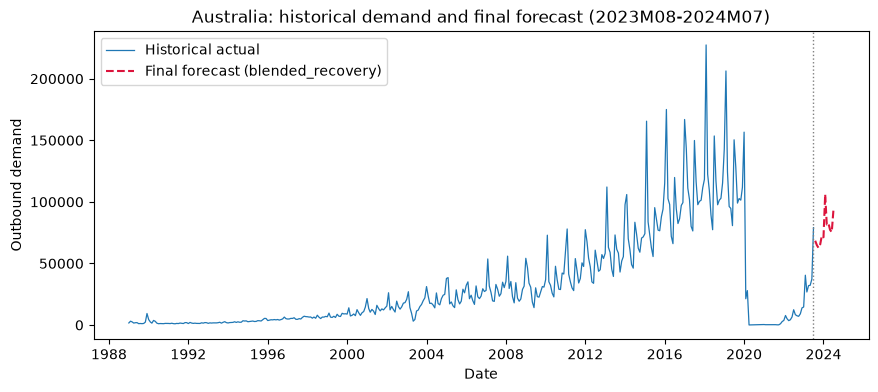

In [41]:
summarise_market("Australia")

<a id="market-japan"></a>
##### Japan (Required market)

Japan: validation performance by model


,mae,mase,mape,n_denominator_pairs,mase_available,denominator_warning
model_label,,,,,,
naive_lag1,131881.20,4.75,72.59,313,True,False
naive_lag12,152226.60,5.49,88.31,313,True,False
seasonal_recovery_naive,86302.34,3.11,46.17,313,True,False
blended_recovery,94679.22,3.41,43.61,313,True,False
sarima,118957.26,4.29,70.36,313,True,False
prophet,77397.03,2.79,37.90,313,True,False
timesfm_2p5_zero_shot,131153.38,4.73,72.76,313,True,False


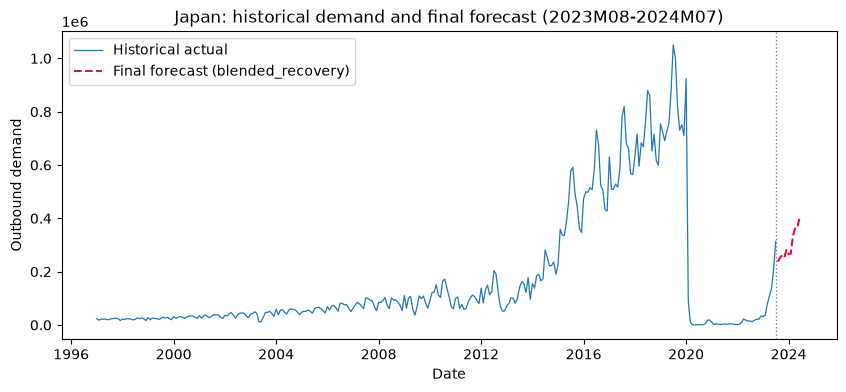

In [42]:
summarise_market("Japan")

<a id="market-new-zealand"></a>
##### New Zealand (Additional market: similar pattern to Australia (r=0.95))

New Zealand: validation performance by model


,mae,mase,mape,n_denominator_pairs,mase_available,denominator_warning
model_label,,,,,,
naive_lag1,6087.60,1.67,55.81,253,True,False
naive_lag12,9589.00,2.62,93.25,253,True,False
seasonal_recovery_naive,4745.20,1.30,46.01,253,True,False
blended_recovery,5550.64,1.52,51.89,253,True,False
sarima,10169.49,2.78,98.57,253,True,False
prophet,10299.60,2.82,100.00,253,True,False
timesfm_2p5_zero_shot,7740.80,2.12,72.60,253,True,False


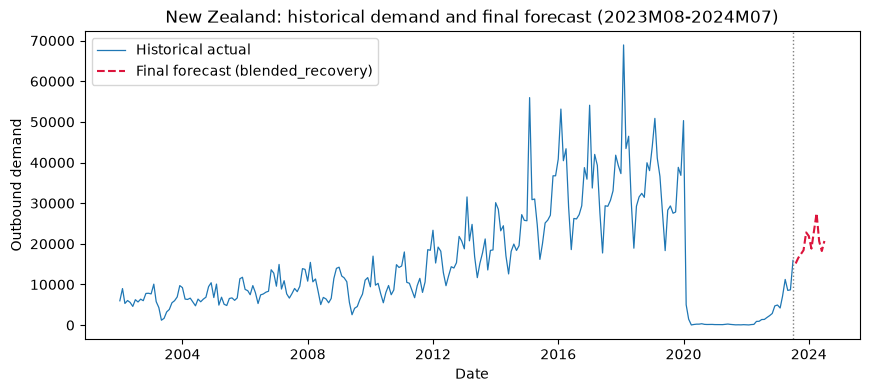

In [43]:
summarise_market("New Zealand")

<a id="market-taiwan-china"></a>
##### Taiwan China (Additional market: contrasting pattern to Japan (r=0.56))

Taiwan China: validation performance by model


,mae,mase,mape,n_denominator_pairs,mase_available,denominator_warning
model_label,,,,,,
naive_lag1,6878.60,0.28,37.07,175,True,False
naive_lag12,15136.60,0.62,93.10,175,True,False
seasonal_recovery_naive,12722.54,0.52,77.05,175,True,False
blended_recovery,9216.18,0.38,53.06,175,True,False
sarima,4606.59,0.19,28.39,175,True,False
prophet,16224.60,0.66,100.00,175,True,False
timesfm_2p5_zero_shot,7740.04,0.32,42.35,175,True,False


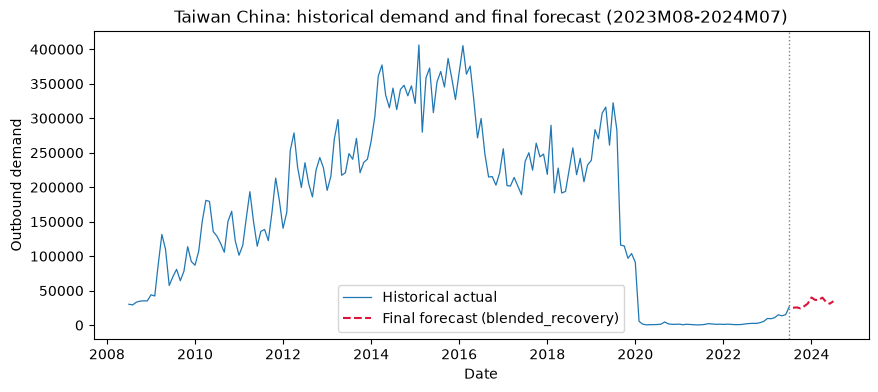

In [44]:
summarise_market("Taiwan China")

<a id="part-iii"></a>
## Part III: Group video and collaboration presentation

<a id="q7"></a>
### Question 7: Group video and collaboration explanation [15 marks]

Submit an 8-12 minute group video according to the Olympus Assignment requirements. Every group member should participate unless the unit chair has approved an alternative arrangement. The video must show code execution, identify the submitted forecast CSV, explain how the CSV can be regenerated from `forecast_submission_wide`, and let each member explain a meaningful part of the submitted work.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q7 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q7:START -->
Record the submitted video filename or link, member participation summary, contribution summary, and any approved alternative arrangement here. Delete this sentence before submission.
<!-- A2:ANSWER:Q7:END -->


<a id="sources"></a>
## Dataset and external source acknowledgement

Acknowledge the TULIP Lab `ISF-TDF2023` dataset and every external source used by your group. Include source URLs or citations, retrieval dates where relevant, and cutoff evidence.

Dataset acknowledgement to include or adapt:

```text
Dataset: ISF-TDF2023.
Publisher: TULIP Lab.
Repository: TULIP Lab Open Data Repository, https://github.com/tulip-lab/open-data.
Licence: CC BY 4.0 unless otherwise stated.
Suggested attribution: TULIP Lab. TULIP Lab Open Data Repository. https://github.com/tulip-lab/open-data. Licensed under CC BY 4.0. Also cite Zhang, Song, Li, Law, and Li (2026).
Associated publication: Zhang, Yishuo; Song, Baobao; Li, Xin; Law, Rob; Li, Gang (2026). Imputation recovery tourism demand forecasting. Annals of Tourism Research, 118, Article 104144. https://doi.org/10.1016/j.annals.2026.104144.
```


<a id="submission-checklist"></a>
## Submission checklist

Before submitting, check that:

- `GROUP_INFO` is complete and required headings/functions/objects/answer markers are preserved.
- The [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md) has been used for MASE/MAPE handling.
- `None` placeholders have been replaced with completed objects, displayed outputs, or concise evidence summaries.
- The notebook runs top to bottom in a clean runtime and can regenerate the final CSV.
- Random seeds or controlled stochastic behaviour are documented where relevant.
- The PDF includes relevant outputs, figures, tables, and explanations.
- Q1 returns a DataFrame with the required row and column order.
- Q2 returns a dictionary with every key in `Q2_AUDIT_FIELDS` and the required forecast-only `None` values.
- Q3 returns `(destination_metrics, aggregate_metrics)` using `DESTINATION_METRIC_COLUMNS` and `AGGREGATE_METRIC_FIELDS`.
- `baseline_validation_comparison` includes both baselines, all 20 destinations, required measure columns, denominator diagnostics, and row counts.
- `baseline_validation_summary` includes aggregate measures for both baselines.
- `validation_forecasts`, `validation_metrics`, and `model_summary` use their required minimum columns and cover the required models.
- `model_summary` contains exactly one `selected=True` row.
- `forecast_submission_wide` has one `Date` column, exactly 20 destination columns, and exactly 12 rows for `2023M08` to `2024M07`.
- `forecast_submission_audit` contains every Q2 audit key, uses `can_align=None`, and reports `is_valid=True` before export.
- The final forecast CSV is exported directly from `forecast_submission_wide` with `index=False` and no manual post-export edits.
- Forecast values are numeric, finite, destination-specific, and not placeholders or copied actual/result values.
- External data sources are cited, cutoff-safe, and included in `external_data/` where required and permitted.
- No credentials, private data, private paths, or restricted links are included.
- The group video and any contribution material follow Olympus instructions.